# Cybersecurity Intrusion Detection - Machine Learning Classification
## Explorative Datenanalyse und Vorbereitung des UNSW-NB15 Datensatzes

###  Forschungsfrage
**Wie gut kann ein Machine-Learning-Modell im UNSW-NB15 Datensatz Angriffe bzw. auffällige Netzwerkverbindungen von normalem Netzwerkverkehr unterscheiden?**

###  Problemstellung
Unternehmen müssen ihre IT-Infrastruktur vor Cyberattacken schützen. Eine kritische Herausforderung ist die **automatische und zuverlässige Erkennung von Angriffsverkehr** im Netzwerk. Manuelle Überprüfung ist nicht skalierbar → Machine Learning ist notwendig.

###  Datensatz
- **Name:** UNSW-NB15 (Australian Centre for Cyber Security)
- **Größe:** ~175.000 Netzwerkverbindungen mit 49 Features
- **Ziel:** Binäre Klassifikation: Normal (0) vs. Angriff (1)
- **Herausforderung:** Class Imbalance (~81% Normal, ~19% Angriff)

###  Unterfragen zu beantworten
1. Welche Features sind für die Angriffserkennung am relevantesten?
2. Wie performt ein einfaches Baseline-Modell (Logistic Regression)?
3. Welche Unterschiede zeigen sich zu komplexeren Modellen (Decision Tree)?
4. Wo sind die Grenzen: Welche Fehlertypen (False Positives vs. False Negatives) treten auf?
5. Ist das beste Modell für Produktions-Deployment geeignet?

###  Phase 1: Exploratory Data Analysis (EDA) & Vorbereitung
Diese Notebook behandelt:
- Explorative Datenanalyse (Verteilungen, Korrelationen, Anomalien)
- Datenbereinigung (fehlende Werte, Ausreißer)
- Feature Engineering (Naming, Encoding, Scaling)
- Train/Test Split mit Stratification

**Output:** ML-ready Trainingsdatensätze für Modelltraining in separaten Notebooks

## Phase 1: Datenimport & Initialisierung

In diesem Abschnitt werden alle erforderlichen Bibliotheken importiert und der UNSW-NB15 Rohdatensatz geladen. Dies ist die Grundlage für alle nachfolgenden Analyseschritte.

In [24]:
# ⚠️ ZUERST: Abhängigkeiten installieren (vor allen Imports!)
!python3 -m pip install --upgrade pip
!python3 -m pip install -r "requirements 3.txt"

# Import helpful packages
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from scipy import stats
import missingno as msno
# from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


# Matplotlib setting for Jupyter Notebook
%matplotlib inline

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
ERROR: Ignored the following versions that require a different python version: 4.0.0 Requires-Python >=3.7,<3.11; 4.1.0 Requires-Python >=3.7,<3.12; 4.1.1 Requires-Python >=3.7,<3.12; 4.1.2 Requires-Python >=3.7,<3.12; 4.10.0 Requires-Python >=3.7,<3.13; 4.11.0 Requires-Python >=3.7,<3.13; 4.12.0 Requires-Python >=3.7,<3.13; 4.12.1 Requires-Python >=3.7,<3.13; 4.12.2 Requires-Python >=3.7,<3.13; 4.13.0 Requires-Python >=3.7,<3.13; 4.14.0 Requires-Python >=3.7,<3.13; 4.15.0 Requires-Python >=3.7,<3.13; 4.15.1 Requires-Python >=3.7,<3.13; 4.16.0 Requires-Python >=3.7,<3.13; 4.16.1 Requires-Python >=3.7,<3.13; 4.2.0 Requires-Python >=3.7,<3.12; 4.3.0 Requires-Python >=3.7,<3.12; 4.3.1 Requires-Python >=3.7,<3.12; 4.3.2 Requires-Python >=3.7,<3.12; 4.4.0 Requires-Python >=3.7,<3.12; 4.5.0 Requires-Python >=3.7,<3.12; 4.5.1 Requires-Pyth

In [25]:
# Style setzen 
sns.set(color_codes=True)
plt.style.use('ggplot')

# Daten laden
INPUT_FILE = "./UNSW_NB15_training-set.csv"
df_raw = pd.read_csv(INPUT_FILE, encoding='latin1')

## Phase 2: Datenverständnis
### Grundlegende Informationen, Struktur und Datentypen

In dieser Phase prüfen wir:
- **Datensatzgröße:** Reihen vs. Spalten
- **Datentypen:** Numerisch vs. Kategorial
- **Verteilung:** Erste/letzte Zeilen, Spaltenliste
- **Qualität:** Grundlegende Statistiken

In [26]:
df = df_raw


# Erste und letzte Zeilen anzeigen
print("Erste 5 Zeilen des Datensatzes:")
display(df.head())
print("\nLetzte 5 Zeilen des Datensatzes:")
display(df.tail())

# Grundlegende Informationen
print("\nGrundlegende Informationen:")
display(df.info())

# Datentypen identifizieren
print("\nDatentypen pro Spalte:")
display(df.dtypes.value_counts())
print("\nListe aller Spalten mit ihren Datentypen:")
display(df.dtypes)

# Separate Listen für numerische und kategoriale Spalten erstellen
numeric_columns = df.select_dtypes(include=['number']).columns.tolist()
categorical_columns = df.select_dtypes(exclude=['number']).columns.tolist()

print(f"\nNumerische Spalten ({len(numeric_columns)}): {numeric_columns}")
print(f"Kategoriale Spalten ({len(categorical_columns)}): {categorical_columns}")

# Größe des Datensatzes
print(f"\nDatensatzgröße: {df.shape[0]} Zeilen und {df.shape[1]} Spalten")

Erste 5 Zeilen des Datensatzes:


,ï»¿id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0



Letzte 5 Zeilen des Datensatzes:


,ï»¿id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
82327,82328,0.000005,udp,-,INT,2,0,104,0,200000.005100,...,1,2,0,0,0,2,1,0,Normal,0
82328,82329,1.106101,tcp,-,FIN,20,8,18062,354,24.410067,...,1,1,0,0,0,3,2,0,Normal,0
82329,82330,0.000000,arp,-,INT,1,0,46,0,0.000000,...,1,1,0,0,0,1,1,1,Normal,0
82330,82331,0.000000,arp,-,INT,1,0,46,0,0.000000,...,1,1,0,0,0,1,1,1,Normal,0
82331,82332,0.000009,udp,-,INT,2,0,104,0,111111.107200,...,1,1,0,0,0,1,1,0,Normal,0



Grundlegende Informationen:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82332 entries, 0 to 82331
Data columns (total 45 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ï»¿id              82332 non-null  int64  
 1   dur                82332 non-null  float64
 2   proto              82332 non-null  object 
 3   service            82332 non-null  object 
 4   state              82332 non-null  object 
 5   spkts              82332 non-null  int64  
 6   dpkts              82332 non-null  int64  
 7   sbytes             82332 non-null  int64  
 8   dbytes             82332 non-null  int64  
 9   rate               82332 non-null  float64
 10  sttl               82332 non-null  int64  
 11  dttl               82332 non-null  int64  
 12  sload              82332 non-null  float64
 13  dload              82332 non-null  float64
 14  sloss              82332 non-null  int64  
 15  dloss              82332 non-null  int64 

...


Datentypen pro Spalte:


int64      30
float64    11
object      4
Name: count, dtype: int64


Liste aller Spalten mit ihren Datentypen:


ï»¿id                  int64
dur                  float64
proto                 object
service               object
state                 object
spkts                  int64
dpkts                  int64
sbytes                 int64
dbytes                 int64
rate                 float64
sttl                   int64
dttl                   int64
sload                float64
dload                float64
sloss                  int64
dloss                  int64
sinpkt               float64
dinpkt               float64
sjit                 float64
djit                 float64
swin                   int64
stcpb                  int64
dtcpb                  int64
dwin                   int64
tcprtt               float64
synack               float64
ackdat               float64
smean                  int64
dmean                  int64
trans_depth            int64
response_body_len      int64
ct_srv_src             int64
ct_state_ttl           int64
ct_dst_ltm             int64
ct_src_dport_l


Numerische Spalten (41): ['ï»¿id', 'dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'label']
Kategoriale Spalten (4): ['proto', 'service', 'state', 'attack_cat']

Datensatzgröße: 82332 Zeilen und 45 Spalten


## Phase 3: Train/Test-Split mit Stratification
### Sichere Aufteilung zur Vermeidung von Data Leakage

**Wichtig:** Ein stratified Split ist kritisch für imbalancierte Klassifikationsprobleme:
- **Stratification:** Erhält exakte Klassenverteilung (81/19) in Train- UND Test-Set
- **Data Leakage Prevention:** Test-Set wird NICHT in Preprocessing verwendet
- **Reproduzierbarkeit:** random_state=42 sichert konsistente Splits

In [27]:

from sklearn.model_selection import train_test_split

# Zielvaiable definieren (Binär-Problem: Angriff ja/nein)
target_column = 'label'  # Original-Name in der CSV - MUSS mit dem Namen in df_raw übereinstimmen

# Features (X) und Target (y) trennen
X = df.drop(columns=[target_column])
y = df[target_column]

# Stratified Train-Test-Split (maßgeblich für imbalancierte Cybersecurity-Daten!)
# - test_size=0.2: 80% Training, 20% Test
# - stratify=y: Erhält exakte Klassenverteilung in beiden Sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, # Reproduzierbarkeit sicherstellen
    stratify=y  # Vermeidet Klassenungleichgewicht-Probleme
)

# Verteilungskontrolle: Überprüfung der Stratification
print(f"Train set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Original class distribution: {y.value_counts(normalize=True)}")
print(f"Train class distribution: {y_train.value_counts(normalize=True)}")
print(f"Test class distribution: {y_test.value_counts(normalize=True)}")

# WICHTIG: Nur mit X_train weiterarbeiten (Data Leakage vermeiden!)
# Arbeits-DataFrame für Preprocessing erstellen (Features + Target)
df = X_train.copy()
df[target_column] = y_train

Train set: 65865 samples
Test set: 16467 samples
Original class distribution: label
1    0.5506
0    0.4494
Name: proportion, dtype: float64
Train class distribution: label
1    0.550596
0    0.449404
Name: proportion, dtype: float64
Test class distribution: label
1    0.550616
0    0.449384
Name: proportion, dtype: float64


## Phase 4: Feature-Engineering - Spaltenumbennung
### Verbesserte Lesbarkeit durch aussagekräftige Feature-Namen

Das UNSW-NB15 Dataset hat kryptische Feature-Namen (z.B. `sbytes`, `spkts`, `tcprtt`). 
Diese werden in aussagekräftige Namen umbenannt (z.B. `bytes_sent`, `packets_sent`, `tcp_round_trip_time`), 
um die Features besser zu verstehen und die Auffindung relevanter Merkmale zu erleichtern.

**Kategorien:**
- Basisdaten (Verbindungs-ID, Protokoll, Dienst)
- Datenmenge & Pakete (Bytes, Pakete, Datenrate)
- Netzwerk-Feature (TTL, Jitter, Datenlast)
- TCP-spezifisch (Window Size, Round Trip Time, Sequence)
- Aggregates (Verbindungszähler für Anomalie-Erkennung)

In [28]:
# Dictionary mit alter -> neuer Spaltenname
rename_dict = {
    # Basisdaten
    "id": "connection_id",
    "dur": "connection_duration_sec",
    "proto": "protocol_type",
    "service": "service_type",
    "state": "connection_state",

    # Datenmenge & Pakete
    "sbytes": "bytes_sent",
    "dbytes": "bytes_received",
    "spkts": "packets_sent",
    "dpkts": "packets_received",
    "rate": "data_rate_bytes_per_sec",

    # TTL & Last
    "sttl": "ttl_sender",
    "dttl": "ttl_receiver",
    "sload": "sender_data_load",
    "dload": "receiver_data_load",

    # Verluste
    "sloss": "packets_lost_sender",
    "dloss": "packets_lost_receiver",

    # Zeit zwischen Paketen
    "sinpkt": "time_between_sender_packets",
    "dinpkt": "time_between_receiver_packets",
    "sjit": "jitter_sender",
    "djit": "jitter_receiver",

    # TCP
    "swin": "tcp_window_sender",
    "stcpb": "tcp_sequence_sender",
    "dtcpb": "tcp_sequence_receiver",
    "dwin": "tcp_window_receiver",
    "tcprtt": "tcp_round_trip_time",
    "synack": "tcp_syn_ack_time",
    "ackdat": "tcp_ack_data_time",

    # Durchschnittswerte
    "smean": "mean_packet_size_sender",
    "dmean": "mean_packet_size_receiver",

    # HTTP / Transaktionen
    "trans_depth": "http_transaction_depth",
    "response_body_len": "server_response_size",

    # Verbindungszähler (Verhaltensmerkmale)
    "ct_srv_src": "connections_per_service",
    "ct_state_ttl": "state_ttl_combinations",
    "ct_dst_ltm": "connections_to_destination_short_term",
    "ct_src_dport_ltm": "connections_from_source_to_dest_port",
    "ct_dst_sport_ltm": "connections_to_dest_from_source_port",
    "ct_dst_src_ltm": "connections_between_source_dest",
    "is_ftp_login": "ftp_login_attempt",
    "ct_ftp_cmd": "ftp_command_count",
    "ct_flw_http_mthd": "http_method_count",
    "ct_src_ltm": "connections_from_source",
    "ct_srv_dst": "connections_to_service",
    "is_sm_ips_ports": "same_ip_port",

    # Zielvariable
    "label": "is_attack"
}

# Umbenennen
df.rename(columns=rename_dict, inplace=True)



# Kontrolle
print(df.columns)

# Umbenennung Spalte 1 (ID):
df.rename(columns={"ï»¿id": "connection_id"}, inplace=True)

Index(['ï»¿id', 'connection_duration_sec', 'protocol_type', 'service_type',
       'connection_state', 'packets_sent', 'packets_received', 'bytes_sent',
       'bytes_received', 'data_rate_bytes_per_sec', 'ttl_sender',
       'ttl_receiver', 'sender_data_load', 'receiver_data_load',
       'packets_lost_sender', 'packets_lost_receiver',
       'time_between_sender_packets', 'time_between_receiver_packets',
       'jitter_sender', 'jitter_receiver', 'tcp_window_sender',
       'tcp_sequence_sender', 'tcp_sequence_receiver', 'tcp_window_receiver',
       'tcp_round_trip_time', 'tcp_syn_ack_time', 'tcp_ack_data_time',
       'mean_packet_size_sender', 'mean_packet_size_receiver',
       'http_transaction_depth', 'server_response_size',
       'connections_per_service', 'state_ttl_combinations',
       'connections_to_destination_short_term',
       'connections_from_source_to_dest_port',
       'connections_to_dest_from_source_port',
       'connections_between_source_dest', 'ftp_login_at

## Phase 5: Fehlende Werte - Diagnoseverfahren
### Prüfung auf Vollständigkeit des Datensatzes

Eine Voraussetzung für saubere ML-Modelle ist die Abwesenheit fehlender Werte. 
Diese Phase identifiziert:
- Welche Spalten haben fehlende Werte?
- Wie viele? (Anzahl und Prozentsatz)
- Sind sie zufällig verteilt oder systematisch?

**Handhabung:**
- Numerische Features: Median-Imputation (robust gegen Ausreißer)
- Kategoriale Features: Modus-Imputation (häufigster Wert)
- Oder: Zeile löschen wenn zu viele fehlend

In [29]:
# Anzahl und Prozentsatz fehlender Werte pro Spalte
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100
missing_info = pd.DataFrame({
    'Fehlende Werte': missing_values,
    'Prozent (%)': missing_percentage
})
missing_info = missing_info[missing_info['Fehlende Werte'] > 0].sort_values('Prozent (%)', ascending=False)

print("Fehlende Werte pro Spalte:")
if len(missing_info) > 0:
    display(missing_info)
else:
    print("Keine fehlenden Werte gefunden")

Fehlende Werte pro Spalte:
Keine fehlenden Werte gefunden


## Phase 6: Univariate Analyse - Einzelne Feature-Verteilungen
### Histogramme, Boxplots, Balkendiagramme

Diese Phase untersucht jedes Feature einzeln:
- **Numerische Features:** Histogramme (Verteilungsform) + Boxplots (Ausreißer)
- **Kategoriale Features:** Balkendiagramme (Häufigkeitsverteilung)
- **Interpretation:** Welche Features sind normalverteilt? Wo sind Ausreißer?

** Erkenntnisse für die Forschungsfrage:**
Numerische Features mit extremen Werten oder multimodalen Verteilungen könnten Indikatoren für Angriffe sein.


Statistische Zusammenfassung numerischer Spalten:


,count,mean,std,min,25%,50%,75%,max
connection_id,65865.0,4.120796e+04,2.377695e+04,1.0,20632.000000,4.122700e+04,6.175500e+04,8.233200e+04
connection_duration_sec,65865.0,9.873107e-01,4.621790e+00,0.0,0.000008,1.400000e-02,7.179180e-01,5.999999e+01
packets_sent,65865.0,1.851982e+01,1.398627e+02,1.0,2.000000,6.000000e+00,1.200000e+01,1.064600e+04
packets_received,65865.0,1.746239e+01,1.226498e+02,0.0,0.000000,2.000000e+00,1.000000e+01,1.101800e+04
bytes_sent,65865.0,7.987310e+03,1.801333e+05,24.0,114.000000,5.340000e+02,1.278000e+03,1.435577e+07
bytes_received,65865.0,1.313970e+04,1.609088e+05,0.0,0.000000,1.780000e+02,9.320000e+02,1.465753e+07
data_rate_bytes_per_sec,65865.0,8.249203e+04,1.486454e+05,0.0,28.600791,2.664298e+03,1.111111e+05,1.000000e+06
ttl_sender,65865.0,1.810683e+02,1.014651e+02,0.0,62.000000,2.540000e+02,2.540000e+02,2.550000e+02
ttl_receiver,65865.0,9.572079e+01,1.166805e+02,0.0,0.000000,2.900000e+01,2.520000e+02,2.530000e+02
sender_data_load,65865.0,6.411705e+07,1.759029e+08,0.0,11182.181640,5.796287e+05,6.514286e+07,5.268000e+09



Häufigkeitsverteilungen kategorialer Spalten:

protocol_type:


protocol_type
tcp       34445
udp       23553
unas       2837
arp         781
ospf        535
sctp        260
any          79
gre          76
ipv6         52
rsvp         52
sep          45
swipe        44
mobile       42
sun-nd       41
pim          33
Name: count, dtype: int64

Anzahl eindeutiger Werte: 131

service_type:


...

Anzahl eindeutiger Werte: 13

connection_state:


connection_state
FIN    31440
INT    27389
CON     5600
REQ     1431
ACC        3
CLO        1
RST        1
Name: count, dtype: int64

Anzahl eindeutiger Werte: 7

attack_cat:


attack_cat
Normal            29600
Generic           15148
Exploits           8896
Fuzzers            4783
DoS                3273
Reconnaissance     2827
Analysis            543
Backdoor            458
Shellcode           298
Worms                39
Name: count, dtype: int64

Anzahl eindeutiger Werte: 10


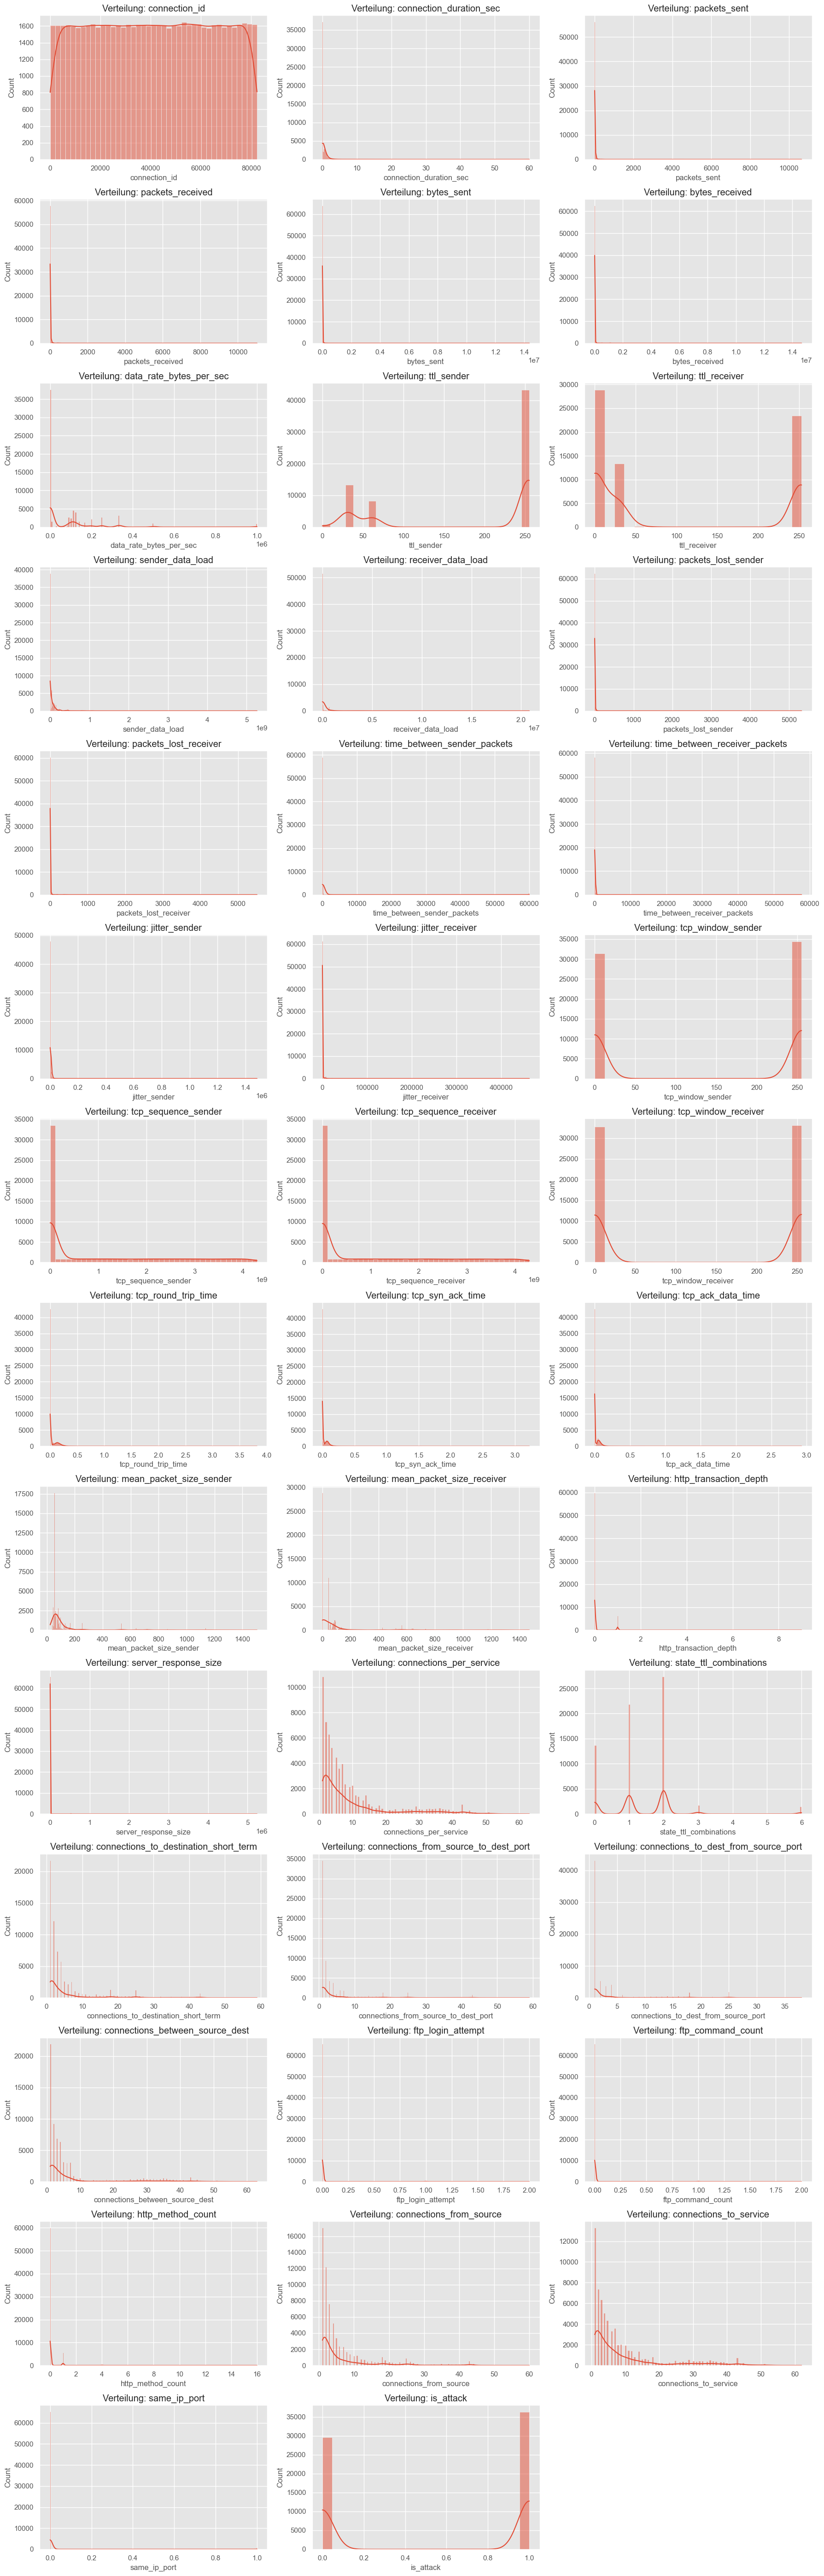

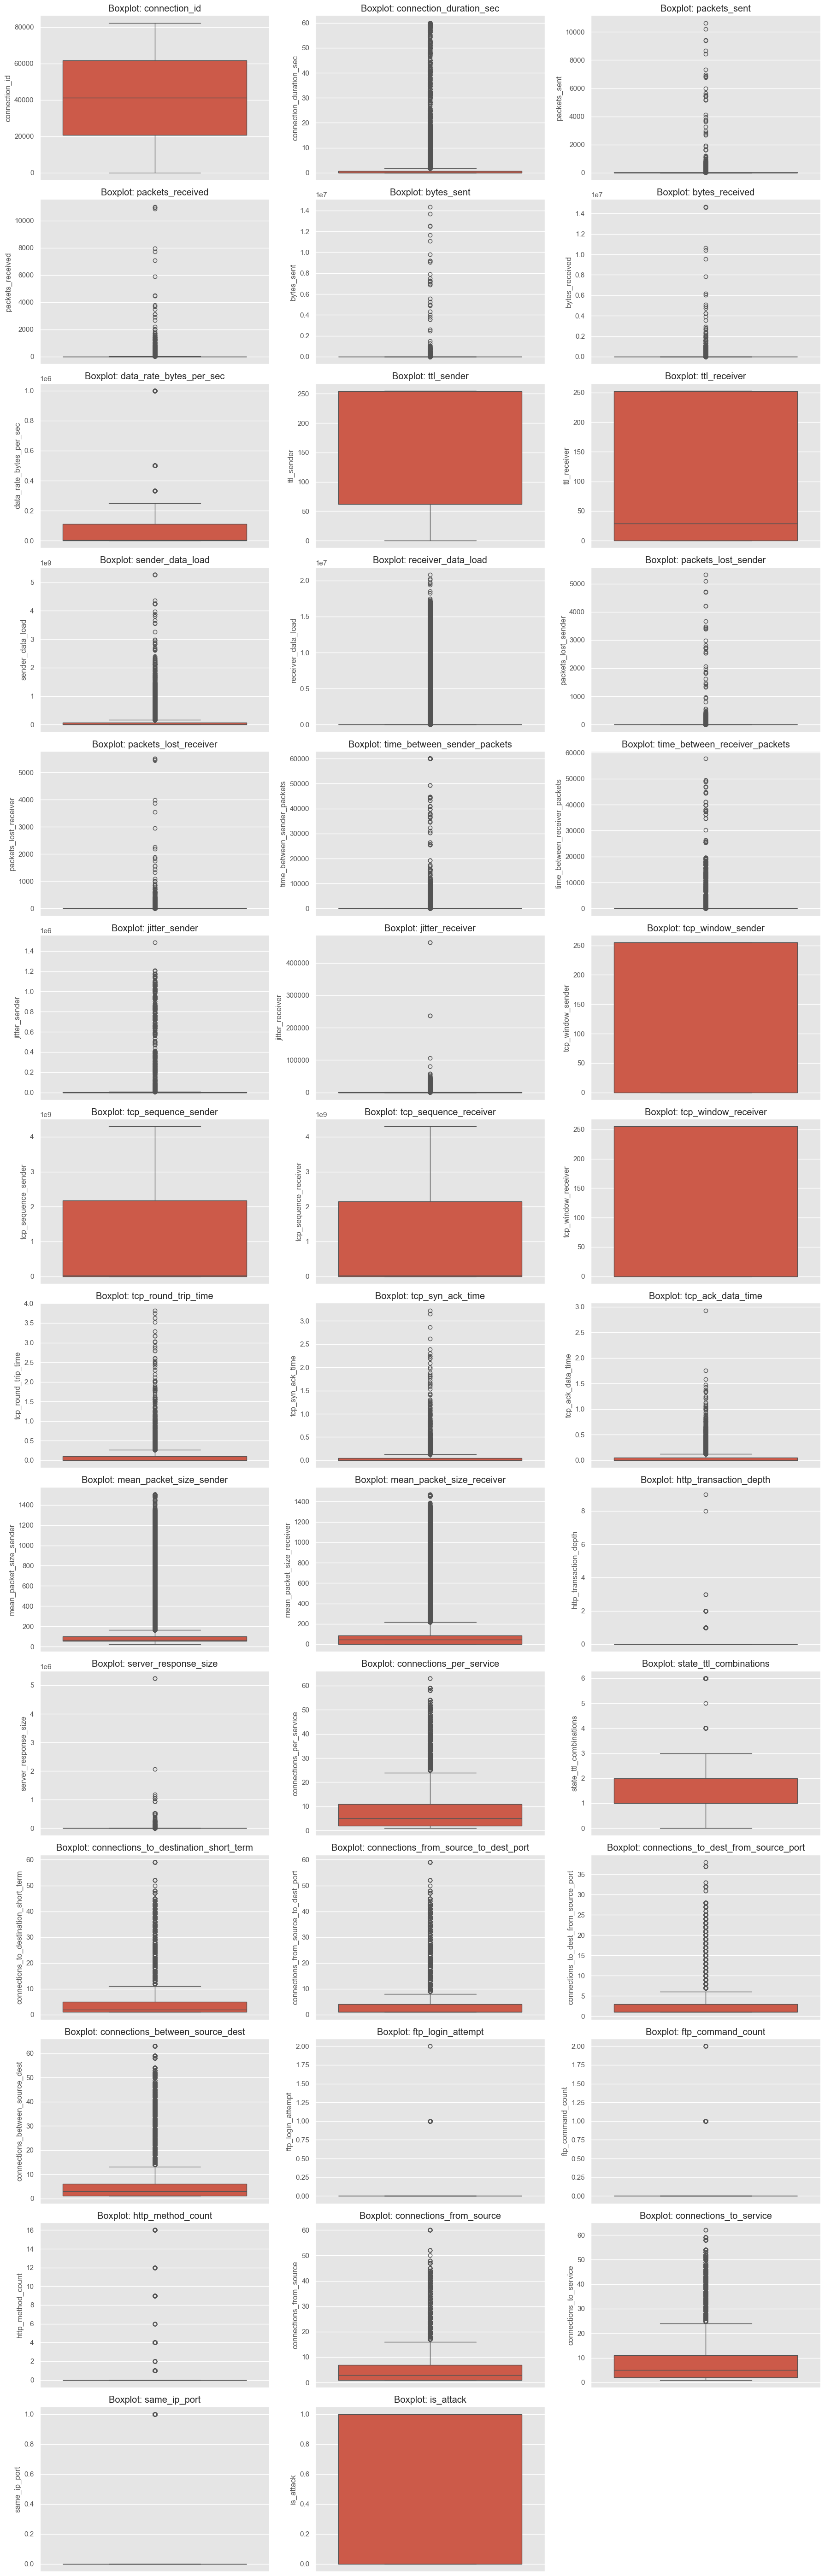

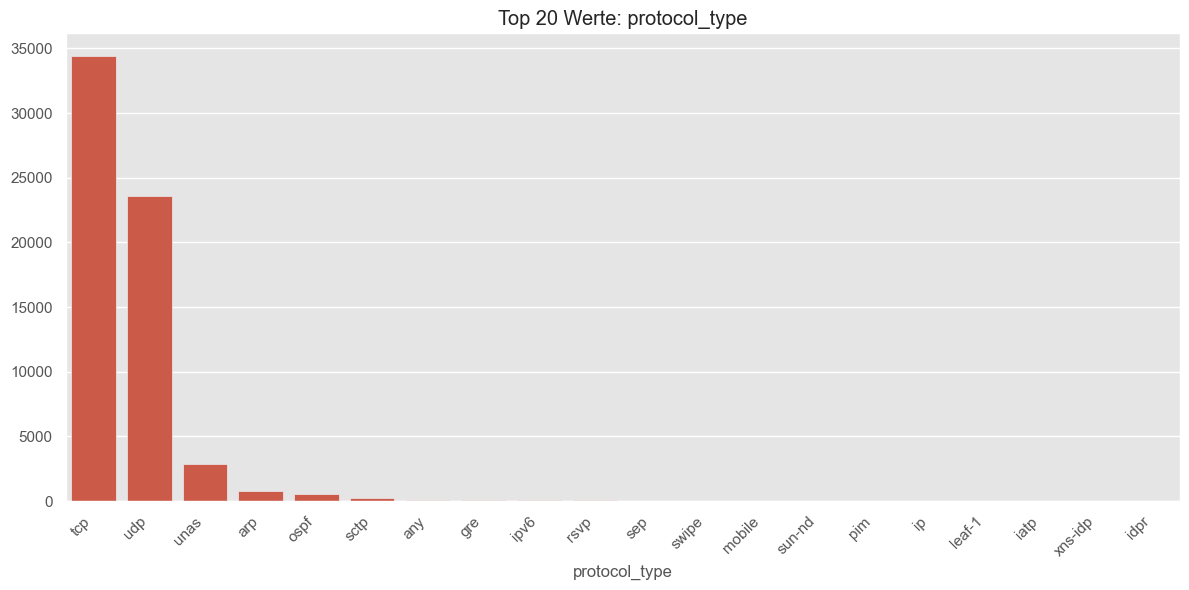

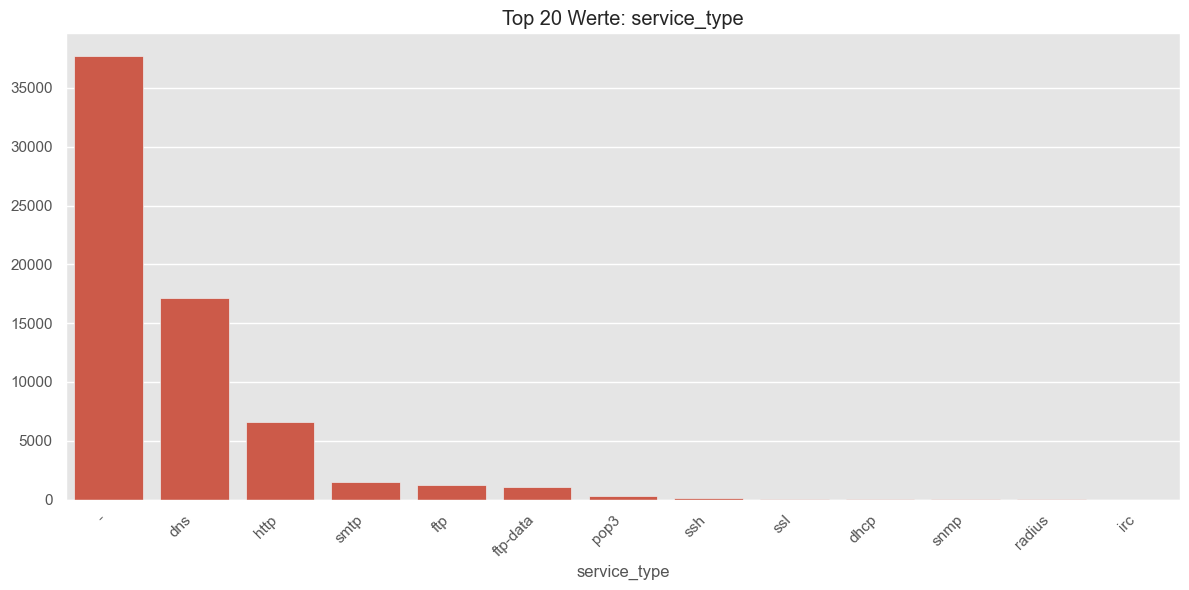

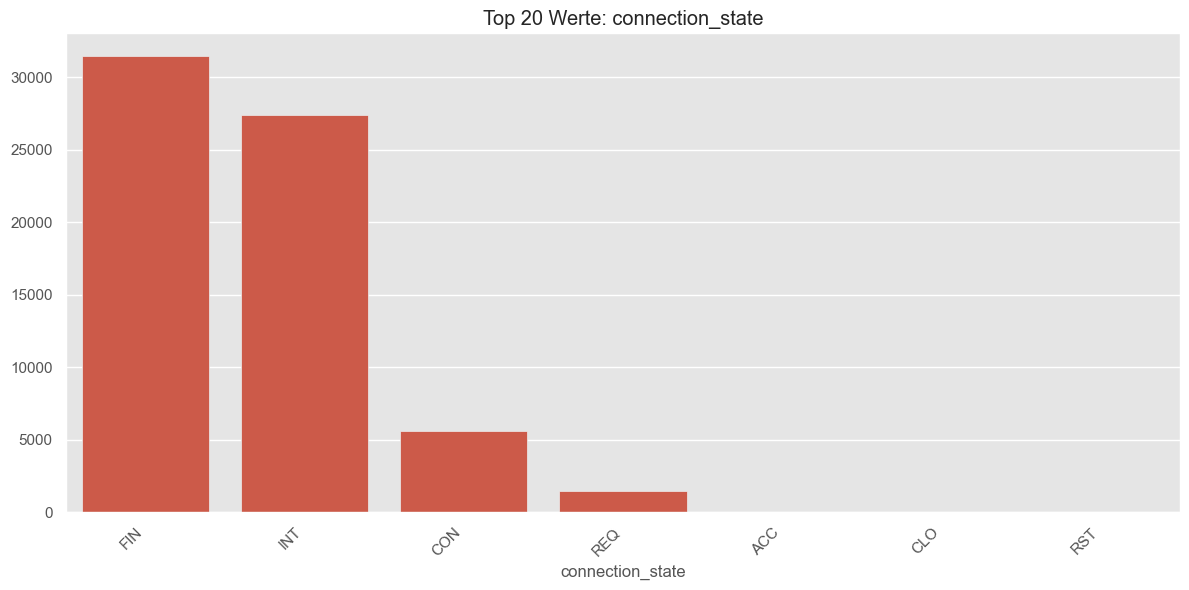

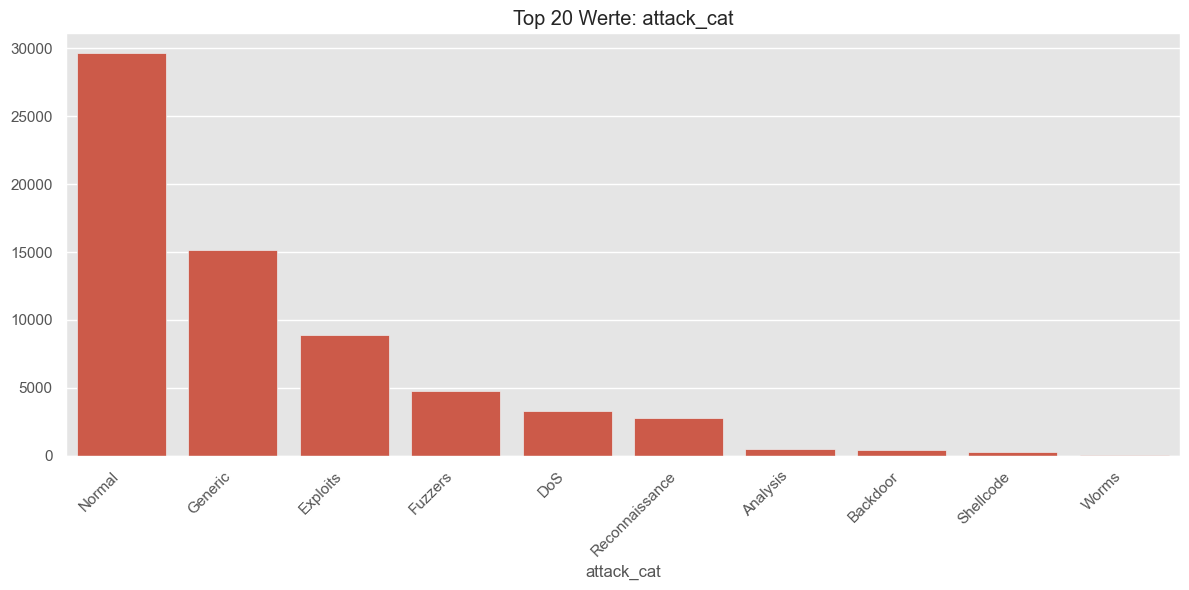

In [ ]:
#===== UNIVARIATE ANALYSE: NUMERISCHE & KATEGORIALE FEATURES =====
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()

# Statistische Zusammenfassung für numerische Spalten
if len(numeric_columns) > 0:
    print("="*80)
    print("STATISTISCHE ZUSAMMENFASSUNG NUMERISCHER SPALTEN")
    print("="*80)
    print(">>> WAS SEHEN WIR HIER?")
    print("    - Mean/Median: Gibt die zentrale Tendenz an")
    print("    - Std Dev: Hohe Standardabweichung deutet auf Variabilität hin")
    print("    - Min/Max: Spannweite hilft Ausreißer zu erkennen")
    print("    - 25%/75%: Quartile zeigen, wo die Hauptmasse der Daten liegt\n")
    display(df[numeric_columns].describe().T)

# Häufigkeitsverteilungen für kategoriale Spalten
if len(categorical_columns) > 0:
    print("\n" + "="*80)
    print("HÄUFIGKEITSVERTEILUNGEN KATEGORIALER SPALTEN")
    print("="*80)
    for col in categorical_columns:
        print(f"\n{col}:")
        print(">>> WAS SEHEN WIR HIER?")
        val_counts = df[col].value_counts()
        if (val_counts[0] / len(df)) > 0.8:
            print(f"    - Extreme Class Imbalance: {val_counts.index[0]} macht {(val_counts[0]/len(df)*100):.1f}% aus")
            print(f"    - Dies kann Modelle beeinflussen → Stratifizierung bei Train/Test Split nötig")
        print(f"    - Anzahl eindeutiger Kategorien: {df[col].nunique()}\n")
        display(val_counts.head(15))

# Histogramme und Dichteplots für numerische Variablen
if len(numeric_columns) > 0:
    print("\n" + "="*80)
    print("HISTOGRAMME & DICHTEPLOTS (Numerische Features)")
    print("="*80)
    rows = int(np.ceil(len(numeric_columns) / 3))
    plt.figure(figsize=(18, rows * 4))
    for i, column in enumerate(numeric_columns):
        plt.subplot(rows, 3, i+1)
        sns.histplot(df[column].dropna(), kde=True, bins=30)
        plt.title(f'Verteilung: {column}')
        plt.xlabel('Wert')
        plt.ylabel('Häufigkeit')
    plt.tight_layout()
    plt.show()
    print("\n>>> INTERPRETATION DER HISTOGRAMME:")
    print("    - Glockenform (normal): Gut für lineare Modelle")
    print("    - Schiefe (skewed): Kann Ausreißer oder Angriffe andeuten")
    print("    - Bimodal: Deutet auf zwei verschiedene Populations-Gruppen hin")

# Box-Plots für numerische Variablen
if len(numeric_columns) > 0:
    print("\n" + "="*80)
    print("BOXPLOTS (Ausreißer-Detektion)")
    print("="*80)
    rows = int(np.ceil(len(numeric_columns) / 3))
    plt.figure(figsize=(18, rows * 4))
    for i, column in enumerate(numeric_columns):
        plt.subplot(rows, 3, i+1)
        sns.boxplot(y=df[column].dropna())
        plt.title(f'Boxplot: {column}')
        plt.ylabel('Wert')
    plt.tight_layout()
    plt.show()
    print("\n>>> INTERPRETATION DER BOXPLOTS:")
    print("    - Box: IQR (Bereich zwischen 25% und 75% der Daten)")
    print("    - Linie in der Box: Median")
    print("    - Punkte außerhalb: Potenzielle Ausreißer (in Cybersecurity = Angriffe?)")

# Balkendiagramme für kategoriale Variablen
if len(categorical_columns) > 0:
    print("\n" + "="*80)
    print("BALKENDIAGRAMME (Kategoriale Features)")
    print("="*80)
    for col in categorical_columns:
        plt.figure(figsize=(12, 6))
        top_cats = df[col].value_counts().head(20)  # Top 20 Kategorien
        sns.barplot(x=top_cats.index, y=top_cats.values, palette='viridis')
        plt.title(f'Top 20 Kategorien: {col}')
        plt.xlabel(col)
        plt.ylabel('Häufigkeit')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
        print(f"\n>>> INTERPRETATION für '{col}':")
        dominant = top_cats.iloc[0]
        total = top_cats.sum()
        print(f"    - Top Kategorie: {top_cats.index[0]} ({dominant/total*100:.1f}% aller Werte)")
        print(f"    - Power-Law-Verteilung: Wenige Kategorien dominieren")
        print(f"    - Empfehlung: Seltene Kategorien zu 'Sonstige' zusammenfassen")

## Phase 7: Ausreißer-Diagnose
### Vergleich: Z-Score vs. IQR-Methode

**Warum Ausreißer-Detection wichtig ist:**
- Ausreißer können Rauschen sein (Messfehler) ODER echte Anomalien (Angriffe!)
- Sie verzerren Modelle, wenn nicht behandelt
- Aber: In Cybersecurity könnten Ausreißer = ANGRIFFE sein

**Zwei Methoden zur Bestimmung von Ausreißern:**
1. **Z-Score (|z| > 3):** Annahme: Normalverteilung. Best für glockenförmige Features.
2. **IQR-Methode (1.5 * IQR):** Robust gegen Extremwerte. Best für schiefe Verteilungen.

**Ergebnis:** Vergleich der beiden Methoden → Entscheidung für eine basierend auf Datenverteilung

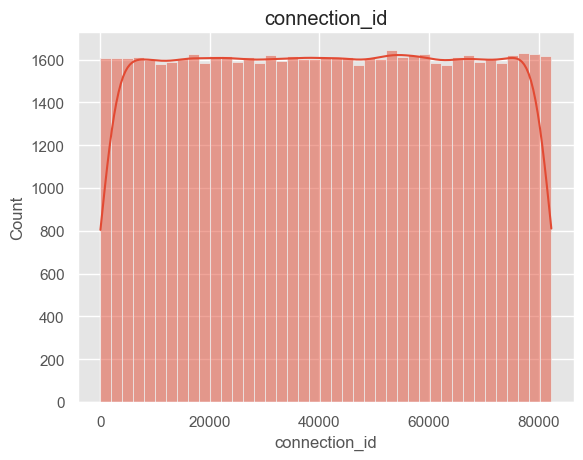

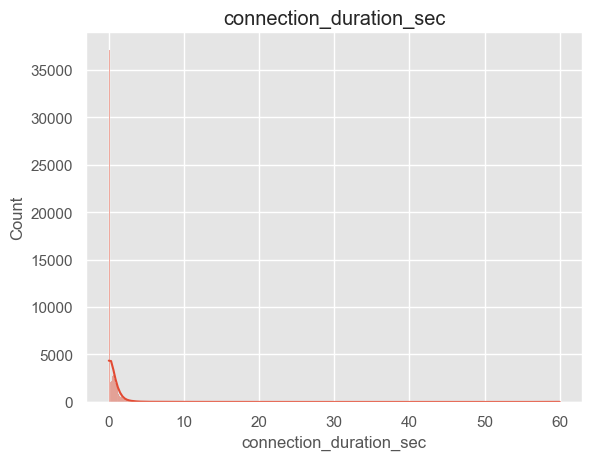

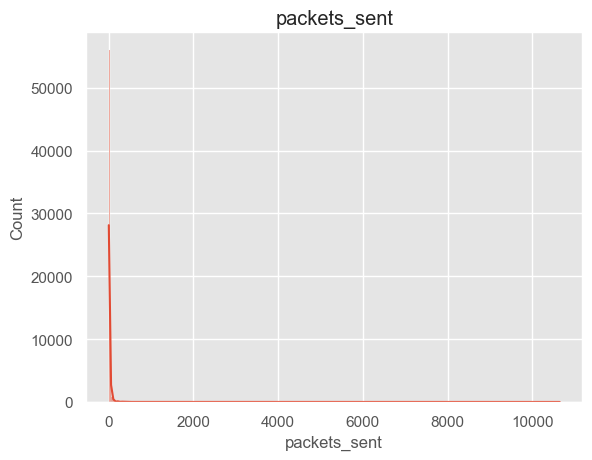

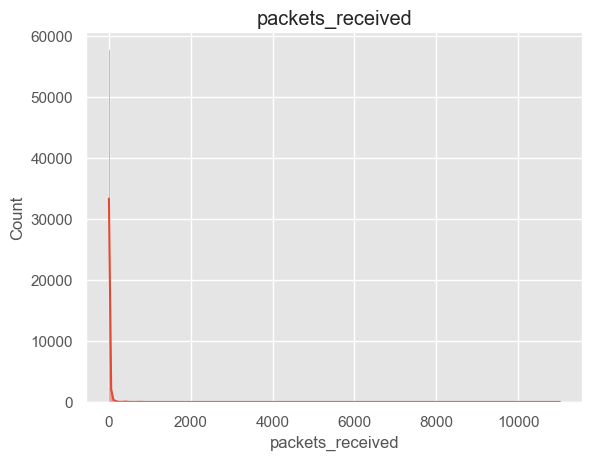

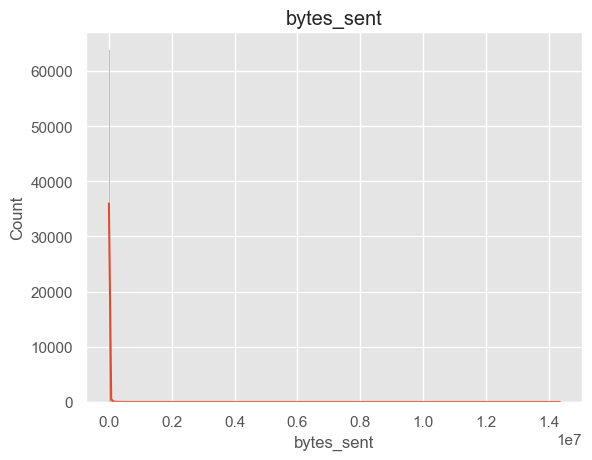

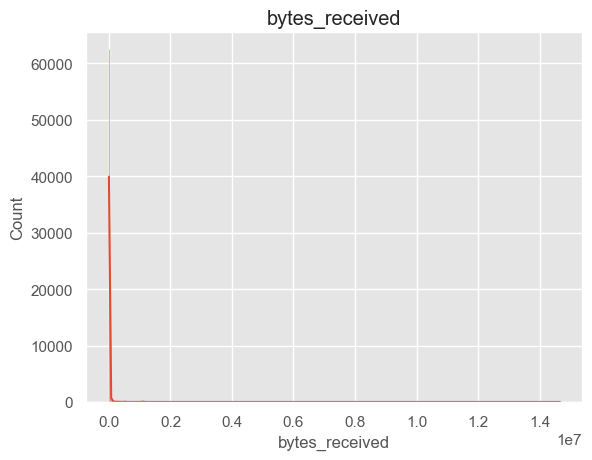

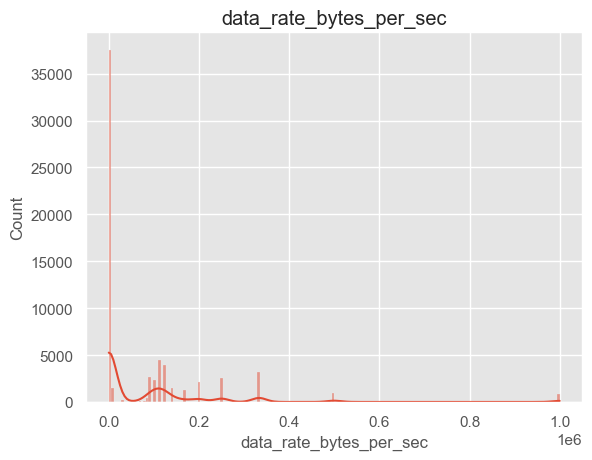

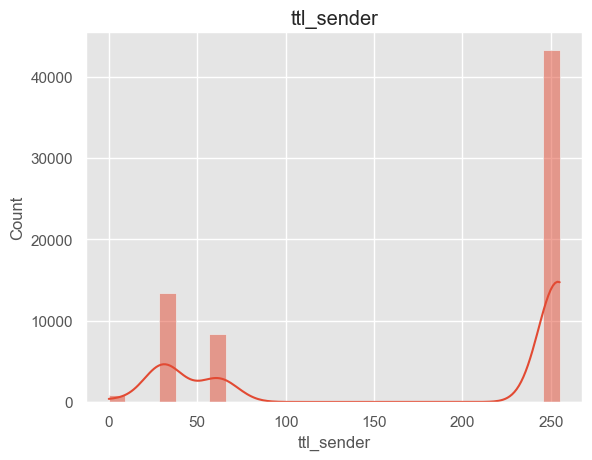

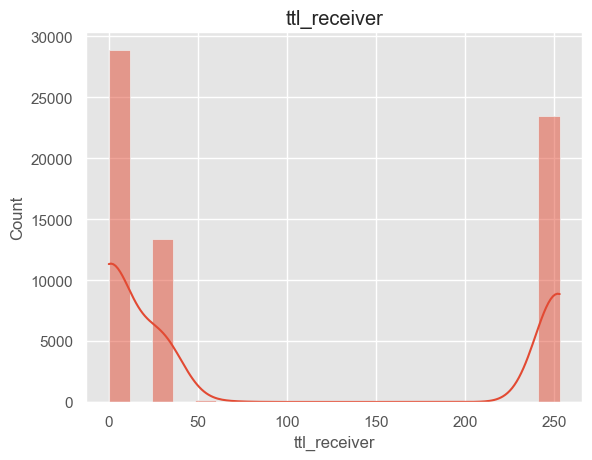

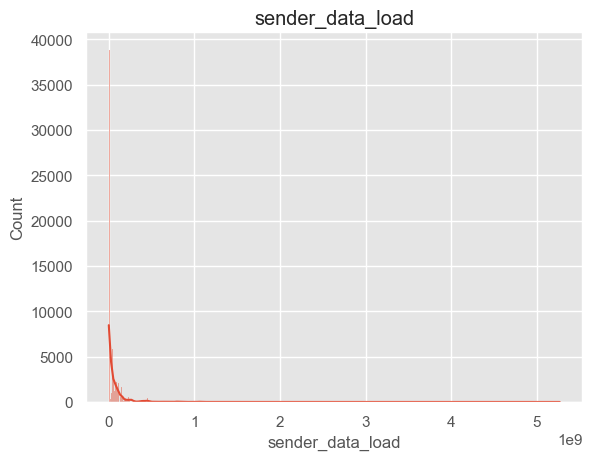

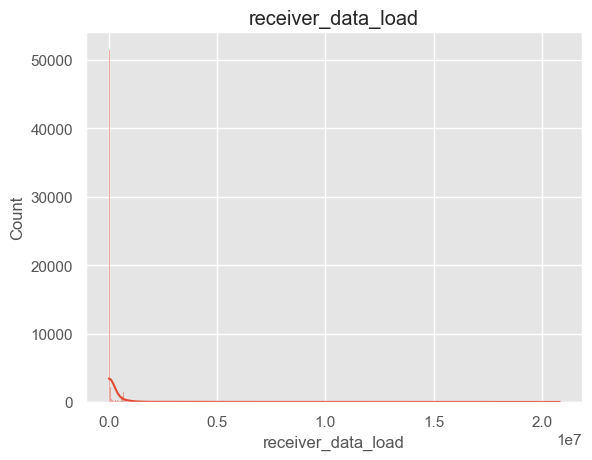

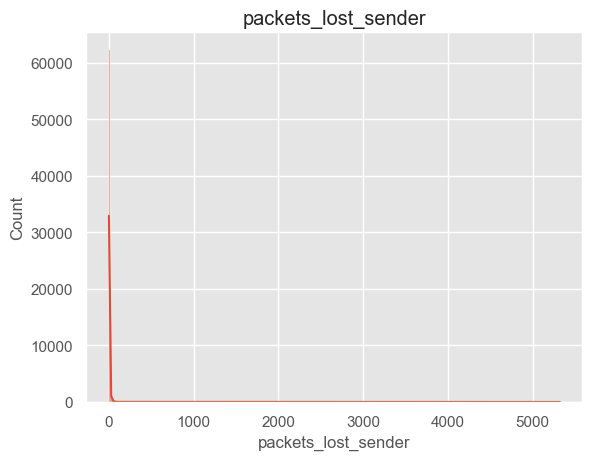

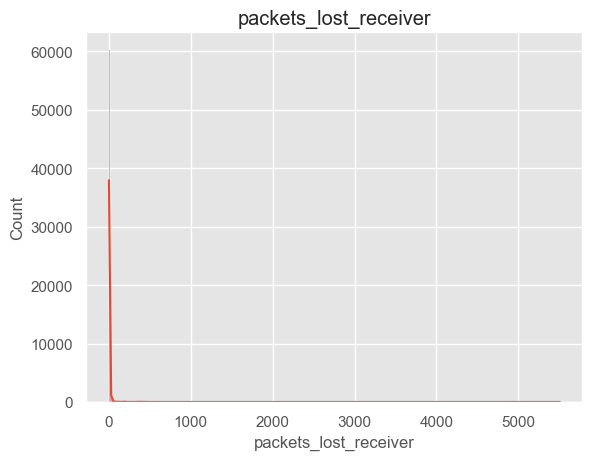

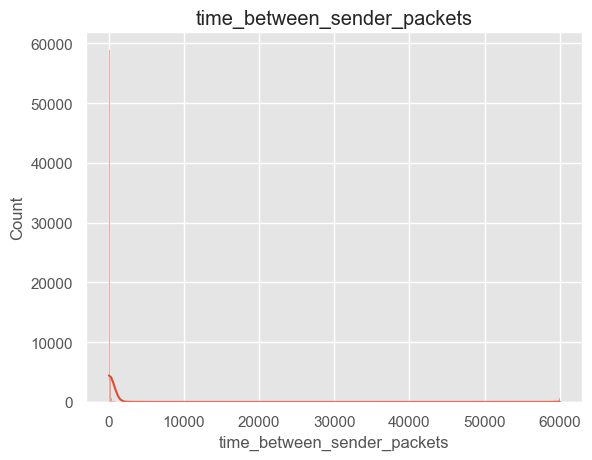

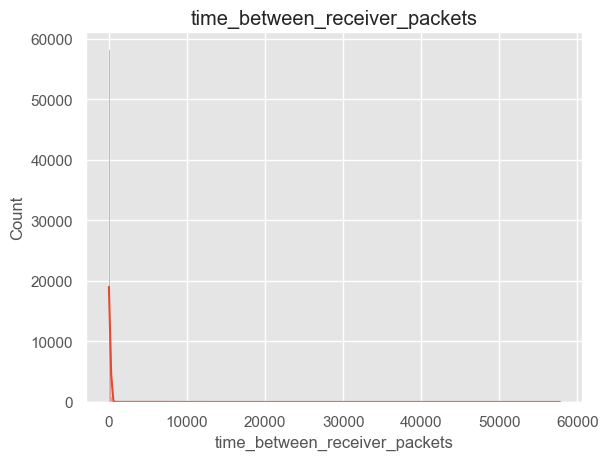

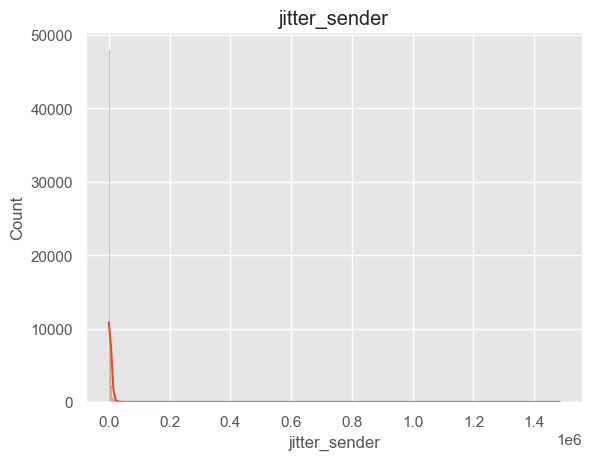

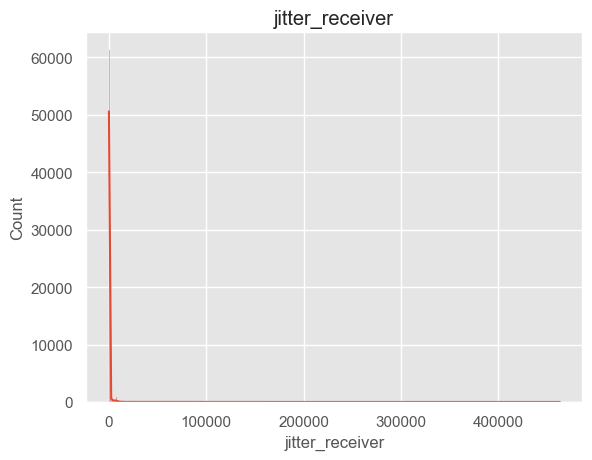

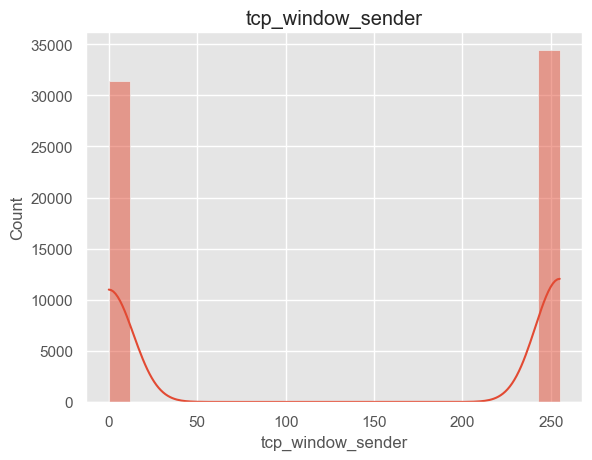

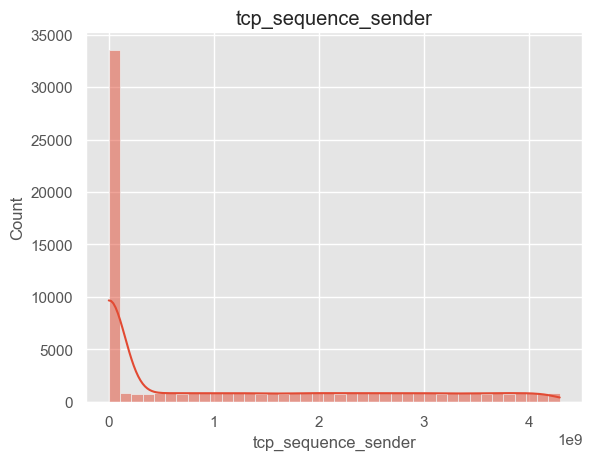

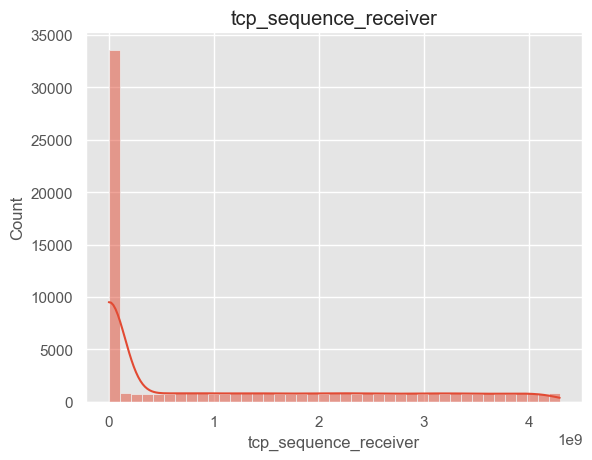

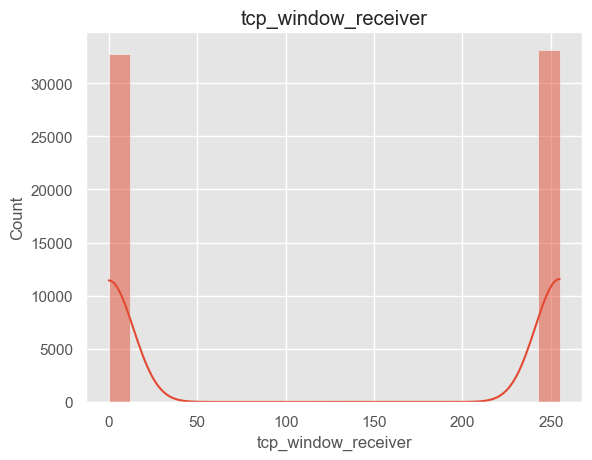

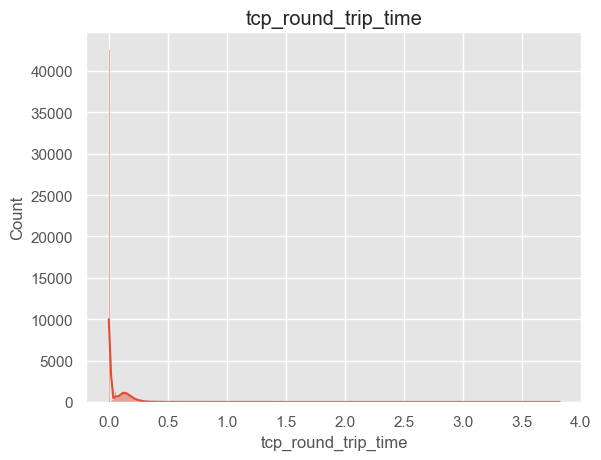

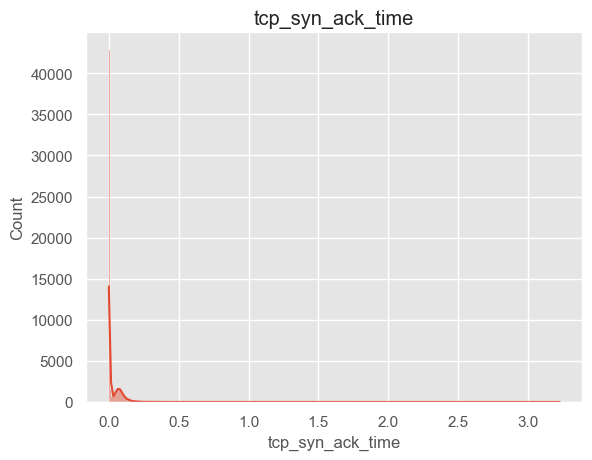

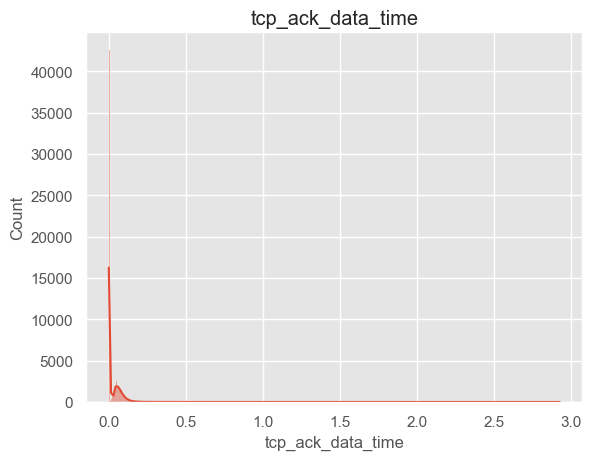

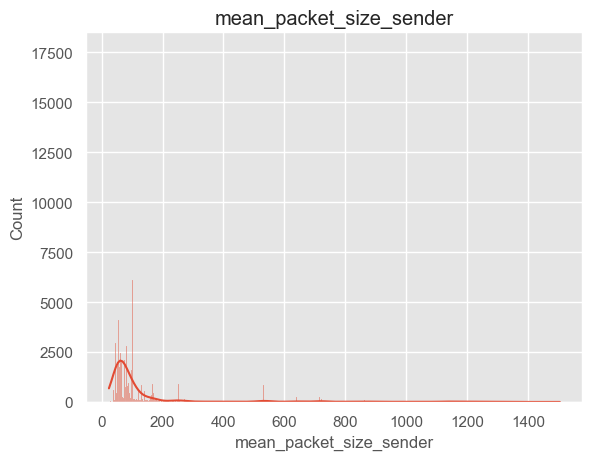

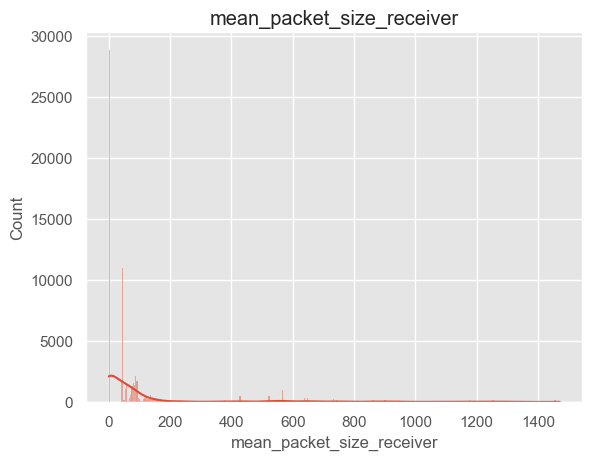

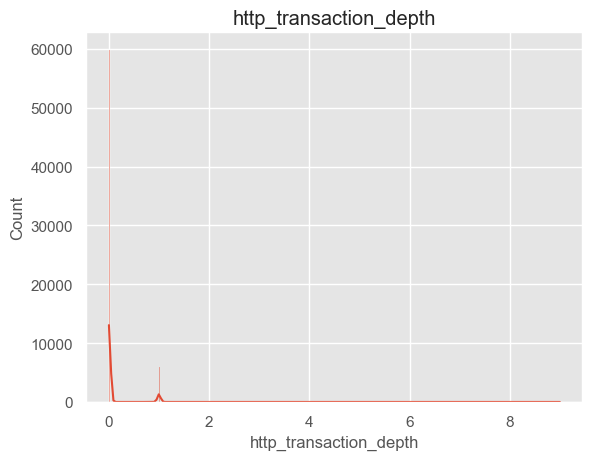

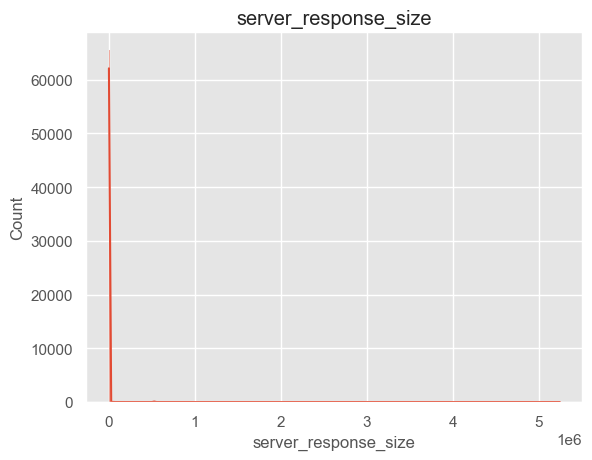

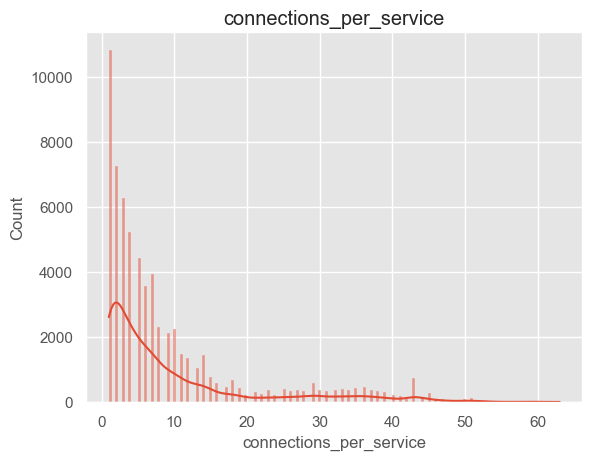

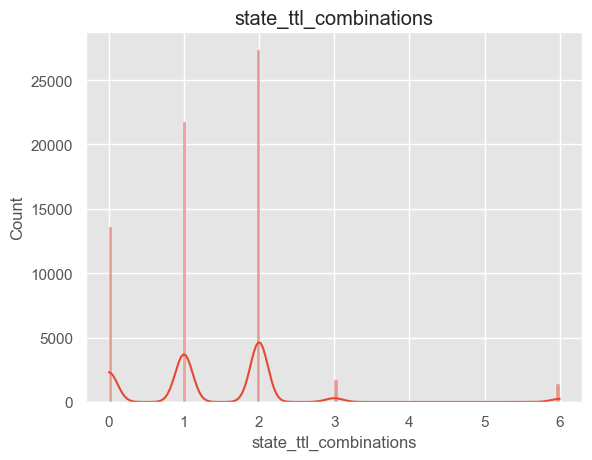

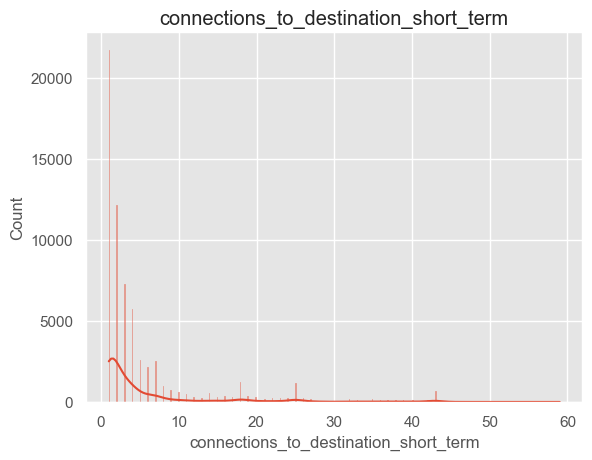

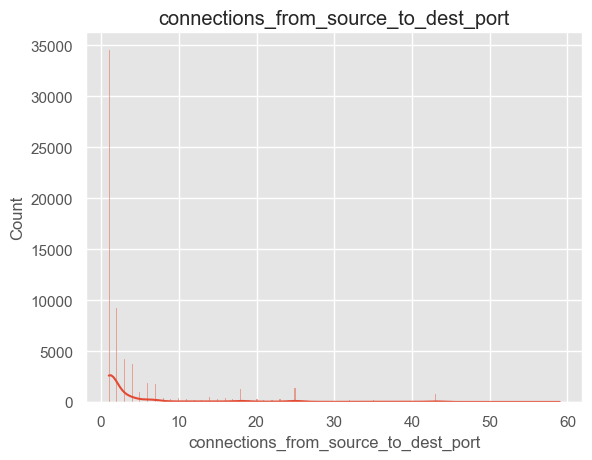

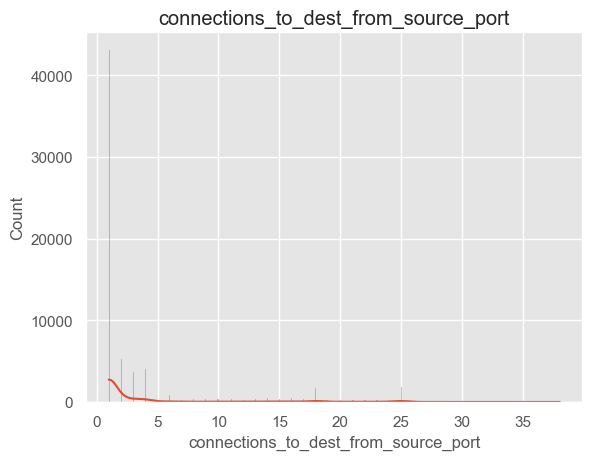

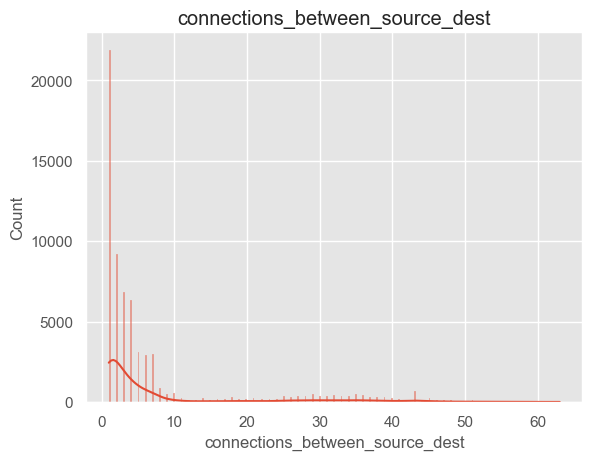

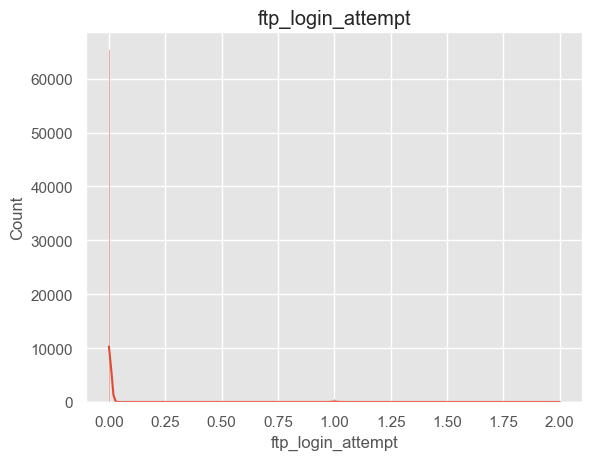

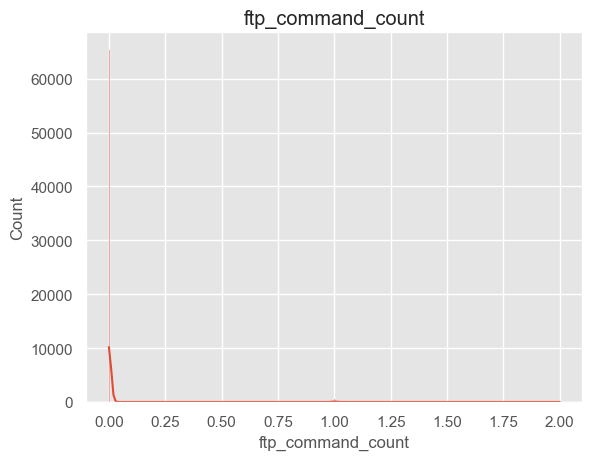

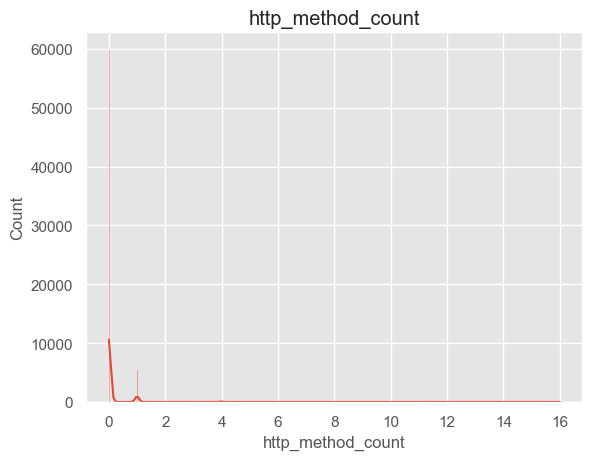

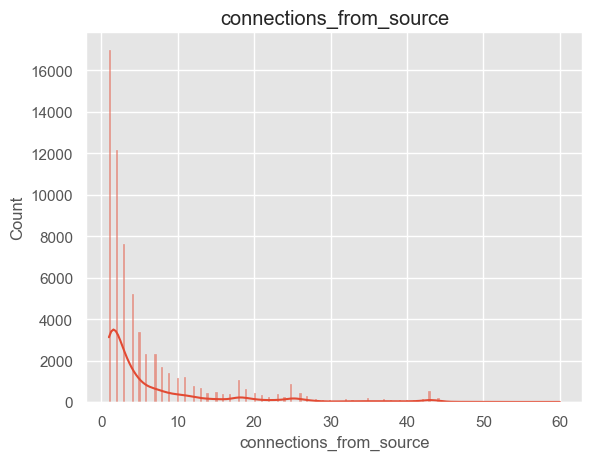

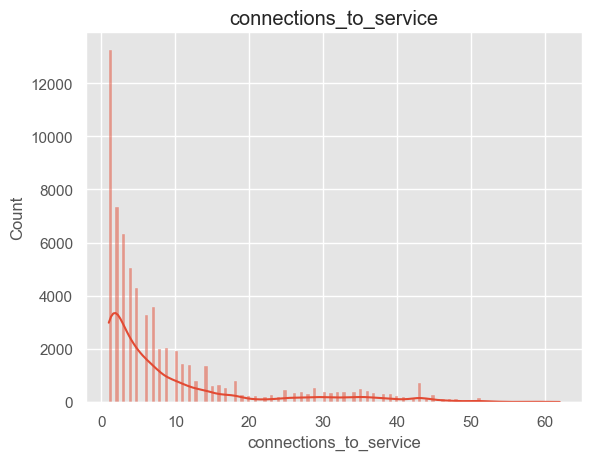

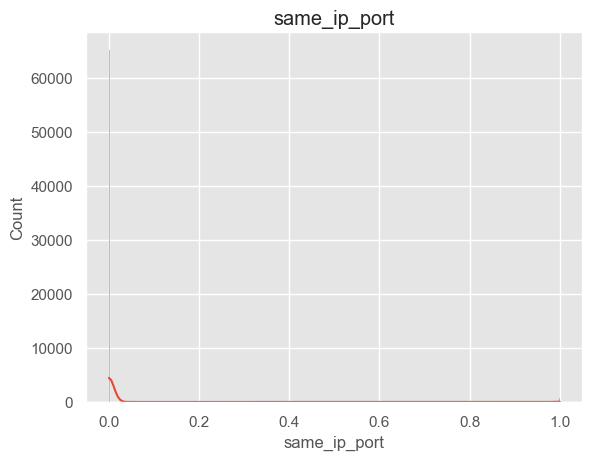

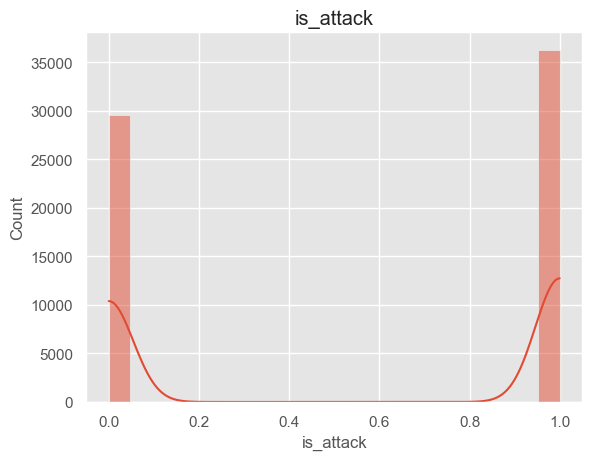

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt


# Verteilung der numerischen Features visuell prüfen
# Ziel: Abschätzen, ob die Verteilung eher normal (glockenförmig) oder schief ist,
# um später zu entscheiden, ob Z‑Score oder IQR als Hauptmethode zur Ausreißer‑Erkennung sinnvoller ist.
# Für nahezu normale Verteilungen eignet sich Z‑Score besser;
# für schiefe oder stark von Extremwerten beeinflusste Verteilungen ist IQR robuster.
for col in numeric_columns:
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()


In [ ]:
z_scores = pd.DataFrame(index=df.index)  # Gleiche Zeilen wie df

for column in numeric_columns:
    # Daten der Spalte
    col_data = df[column]
    
    # a) Wenn keine NAs vorhanden sind, einfach den Z-Score berechnen
    if col_data.isnull().sum() == 0:
        z_scores[column] = np.abs(stats.zscore(col_data))
    
    # b) Wenn NAs vorhanden sind:
    else:
        # Nur die non-null-Werte extrahieren
        non_null_data = col_data.dropna()
        
        # Z-Score berechnen für nur diese Werte
        z = stats.zscore(non_null_data)
        
        # Als Series anlegen und den Index wie die non-null-Werte setzen
        z_series = pd.Series(z, index=non_null_data.index)
        
        # Anschließend in die entsprechende Spalte des z_scores-Datensatzes übernehmen
        # und für die NA-Positionen von df automatisch mit NaN auffüllen
        z_scores[column] = z_series

# Jetzt hast du ein DataFrame z_scores mit gleicher Zeilenlänge wie df, 
# in dem für jede numerische Spalte die Z-Scores stehen (NaN an den Stellen, an denen df[column] fehlte).

# Ausreißer identifizieren (|z| > 3)
print("Anzahl der Ausreißer pro numerischer Spalte (|z| > 3):")
display((z_scores > 3).sum())

# IQR-Methode bleibt unverändert
outliers_count = {}
for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[column] < (Q1 - 1.5 * IQR)) | (df[column] > (Q3 + 1.5 * IQR))).sum()
    outliers_count[column] = outliers

print("\nAnzahl der Ausreißer pro Spalte (IQR-Methode):")
display(pd.Series(outliers_count))

print("\n>>> WAS SEHEN WIR HIER (Z-Score vs. IQR Vergleich)?")
print("    - Z-Score (|z| > 3): Identifiziert extreme Werte (~0.3% bei Normalverteilung)")
print("    - IQR-Methode (1.5×IQR): Identifiziert Box-Plot-Ausreißer (robuster für schiefe Daten)")
print("    → Unterschiede deuten auf Verteilungsform hin:")
print("      • Ähnliche Zeilen: Feature ist ca. normalverteilt")
print("      • IQR > Z-Score: Feature ist rechtsschief (in Cybersecurity oft der Fall!)")
print("      • Z-Score > IQR: Feature hat extreme Schwänze")
print("\n>>> ENTSCHEIDUNG FÜR AUSREISSER-BEHANDLUNG:")
print("    ✓ IQR-Methode wird verwendet (Standard für Netzwerk-Daten)")
print("    ✓ Grund: Unabhängig von Normalverteilungs-Annahmen")
print("    ✓ Effekt: Entfernt Zeilen mit extremen Netzwerk-Mustern → oft sind das Angriffe!")

Anzahl der Ausreißer pro numerischer Spalte (|z| > 3):


connection_id                               0
connection_duration_sec                   835
packets_sent                              140
packets_received                          507
bytes_sent                                 69
bytes_received                            385
data_rate_bytes_per_sec                   826
ttl_sender                                  0
ttl_receiver                                0
sender_data_load                         1096
receiver_data_load                       2196
packets_lost_sender                        89
packets_lost_receiver                     376
time_between_sender_packets               721
time_between_receiver_packets             350
jitter_sender                             464
jitter_receiver                           457
tcp_window_sender                           0
tcp_sequence_sender                         0
tcp_sequence_receiver                       0
tcp_window_receiver                         0
tcp_round_trip_time               


Anzahl der Ausreißer pro Spalte (IQR-Methode):


connection_id                                0
connection_duration_sec                   4640
packets_sent                              8133
packets_received                          7117
bytes_sent                                7393
bytes_received                            9867
data_rate_bytes_per_sec                   4960
ttl_sender                                   0
ttl_receiver                                 0
sender_data_load                          5404
receiver_data_load                       14473
packets_lost_sender                       4383
packets_lost_receiver                     9016
time_between_sender_packets               4500
time_between_receiver_packets             3727
jitter_sender                             5050
jitter_receiver                           6797
tcp_window_sender                            0
tcp_sequence_sender                          0
tcp_sequence_receiver                        0
tcp_window_receiver                          0
tcp_round_tri

## Phase 8: Ausreißer-Entfernung (IQR-Methode)
### Umsetzung: Zeilen mit extremen Werten löschen

Nach Diagnose: **IQR-Methode gewählt** (robust, weniger abhängig von Verteilungsannahmen)

**Logik:**
1. Q1 = 25. Perzentil, Q3 = 75. Perzentil
2. IQR = Q3 - Q1 (Interquartilsabstand)
3. Lower Bound = Q1 - 1.5 * IQR
4. Upper Bound = Q3 + 1.5 * IQR
5. Lösche Zeilen, wo ANY Feature außerhalb dieser Grenzen liegt

**⚠️ Wichtig:** Nur Ausreißer in numerischen Features entfernen, kategoriale Features bleiben

In [33]:
# IQR-Berechnung und Ausreißer-Entfernung nach IQR-Methode
# Schritt 1: Quartile und Interquartilsabstand (IQR) für alle numerischen Spalten berechnen
Q1 = df[numeric_columns].quantile(0.25)          # 25%-Perzentil (Q1)
Q3 = df[numeric_columns].quantile(0.75)          # 75%-Perzentil (Q3)
IQR = Q3 - Q1                                    # Interquartilsabstand

# Schritt 2: Grenzen für Ausreißer nach der Boxplot-Regel (1.5 * IQR) bestimmen
lower_bound = Q1 - 1.5 * IQR                     # Untere Grenze
upper_bound = Q3 + 1.5 * IQR                     # Obere Grenze

# Schritt 3: Maske erstellen, die alle Zeilen ohne Ausreißer in allen numerischen Spalten markiert
# True = keine Ausreißer in dieser Zeile, False = mindestens ein Ausreißer in einer Spalte
mask_no_outliers_iqr = ~(
    (df[numeric_columns] < lower_bound) |        # Werte unterhalb der unteren Grenze
    (df[numeric_columns] > upper_bound)          # oder oberhalb der oberen Grenze
).any(axis=1)                                    # mindestens eine Spalte hat Ausreißer

# Schritt 4: DataFrame nur mit Zeilen ohne Ausreißer erstellen und anzeigen
df_no_outliers_iqr = df[mask_no_outliers_iqr].copy()
print(df_no_outliers_iqr)

# ===== IMPACT ANALYSE: Dokumentation der Ausreißer-Entfernung =====
print("\n" + "=" * 80)
print("IMPACT ANALYSE: Ausreißer-Entfernung")
print("=" * 80)

initial_rows = X_train.shape[0]
final_rows = df_no_outliers_iqr.shape[0]
deleted_rows = initial_rows - final_rows
deleted_pct = (deleted_rows / initial_rows) * 100

print(f"\n Allgemeine Statistik:")
print(f"   Zeilen vor Ausreißer-Entfernung: {initial_rows:,}")
print(f"   Zeilen nach Ausreißer-Entfernung: {final_rows:,}")
print(f"   Gelöschte Zeilen: {deleted_rows:,} ({deleted_pct:.2f}%)")

# Nach Attack-Label analysieren
print(f"\n Impact nach Attack-Label:")
normal_before = (df['is_attack'] == 0).sum()
attack_before = (df['is_attack'] == 1).sum()
normal_after = (df_no_outliers_iqr['is_attack'] == 0).sum()
attack_after = (df_no_outliers_iqr['is_attack'] == 1).sum()

normal_lost = normal_before - normal_after
attack_lost = attack_before - attack_after
normal_lost_pct = (normal_lost / normal_before * 100) if normal_before > 0 else 0
attack_lost_pct = (attack_lost / attack_before * 100) if attack_before > 0 else 0

print(f"   Normal-Samples:  {normal_before:,} → {normal_after:,} (verloren: {normal_lost:,} = {normal_lost_pct:.2f}%)")
print(f"   Attack-Samples:  {attack_before:,} → {attack_after:,} (verloren: {attack_lost:,} = {attack_lost_pct:.2f}%)")

# Bewertung
print(f"\n✅ BEWERTUNG:")
if attack_lost_pct < 10:
    print(f"   ✅ Akzeptabel: Weniger als 10% Attack-Samples verloren")
    print(f"   → Ausreißer-Entfernung ist datensatz-verträglich")
else:
    print(f"   ⚠️ Warnung: {attack_lost_pct:.1f}% Attack-Samples verloren")
    print(f"   → Könnte für Minority-Class-Detection problematisch sein")

# Begründung für IQR-Wahl
print(f"\n METHODENBEGRÜNDUNG - Warum IQR?")
print(f"   1. Robustheit: IQR-Methode ist unabhängig von Normalverteilungs-Annahmen")
print(f"   2. Praxis: 1.5 × IQR ist Standard in Boxplot-Analyse")
print(f"   3. Sicherheit: Angriffe zeigen oft extreme Netzwerk-Muster")
print(f"      → IQR erfasst sie zuverlässig, ohne zu aggressiv zu sein")
print(f"   4. Verteilungen: Viele Features sind rechtsschief (nicht normal)")
print(f"      → Z-Score würde hier unzuverlässig sein")

       connection_id  connection_duration_sec protocol_type service_type  \
3574            3575                 0.654355           tcp            -   
24647          24648                 0.058395           udp            -   
54061          54062                 0.000010          unas            -   
47432          47433                 0.213658           tcp         http   
82190          82191                 0.492845           tcp            -   
...              ...                      ...           ...          ...   
2629            2630                 0.000009          unas            -   
79518          79519                 0.863703           tcp            -   
717              718                 0.000005     ipv6-opts            -   
78595          78596                 0.619101           tcp            -   
59006          59007                 0.350092           tcp            -   

      connection_state  packets_sent  packets_received  bytes_sent  \
3574             

## Phase 9: Bivariate Analyse - Beziehungen zwischen Features
### Korrelationen, Feature-Abhängigkeiten

Diese Phase untersucht **Wechselwirkungen zwischen Features**:
- **Numerisch-Numerisch:** Korrelationsmatrix (Pearson), Top-10 Paare
- **Kategorial-Numerisch:** Boxplots nach Kategorie
- **Kategorial-Kategorial:** Kreuztabellen

** Erkenntnisse für die Forschungsfrage:**
- Stark korrelierte Features könnten Multikollinearität verursachen
- Features mit hohem Unterschied zwischen Normal/Angriff sind relevant
- Feature-Interaktionen könnten für ML-Modelle wichtig sein

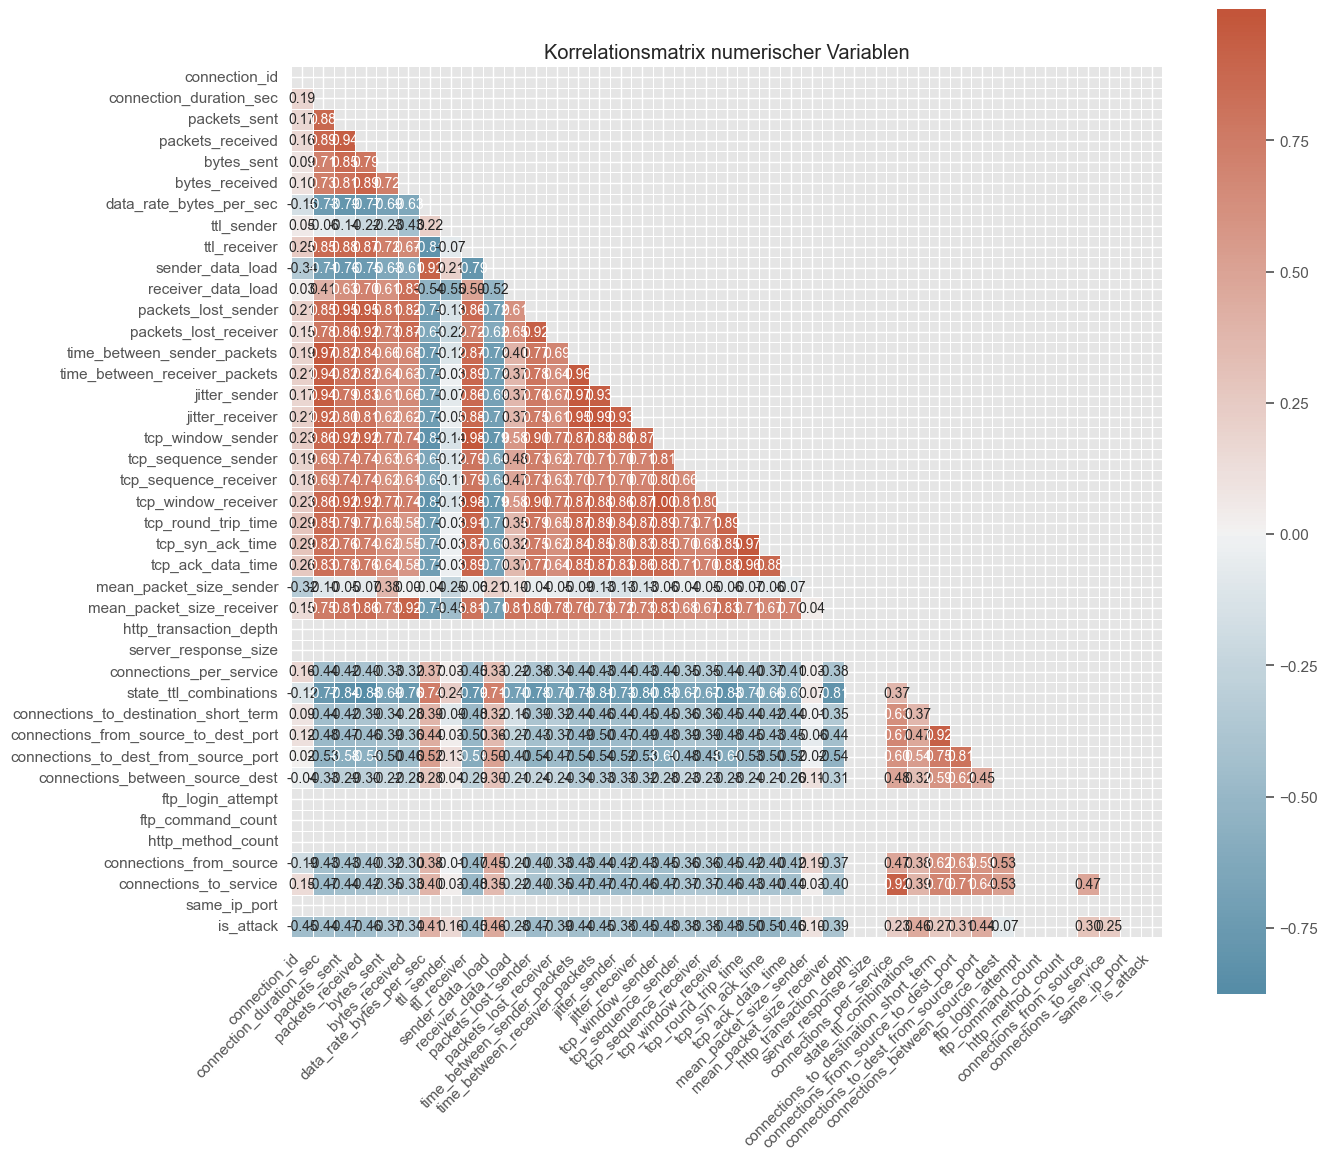

Top 10 stärkste Korrelationen:


tcp_window_receiver            tcp_window_sender                0.999582
tcp_window_sender              tcp_window_receiver              0.999582
time_between_receiver_packets  jitter_receiver                  0.988741
jitter_receiver                time_between_receiver_packets    0.988741
tcp_window_sender              ttl_receiver                     0.981976
ttl_receiver                   tcp_window_sender                0.981976
tcp_window_receiver            ttl_receiver                     0.981934
ttl_receiver                   tcp_window_receiver              0.981934
tcp_syn_ack_time               tcp_round_trip_time              0.972352
tcp_round_trip_time            tcp_syn_ack_time                 0.972352
dtype: float64

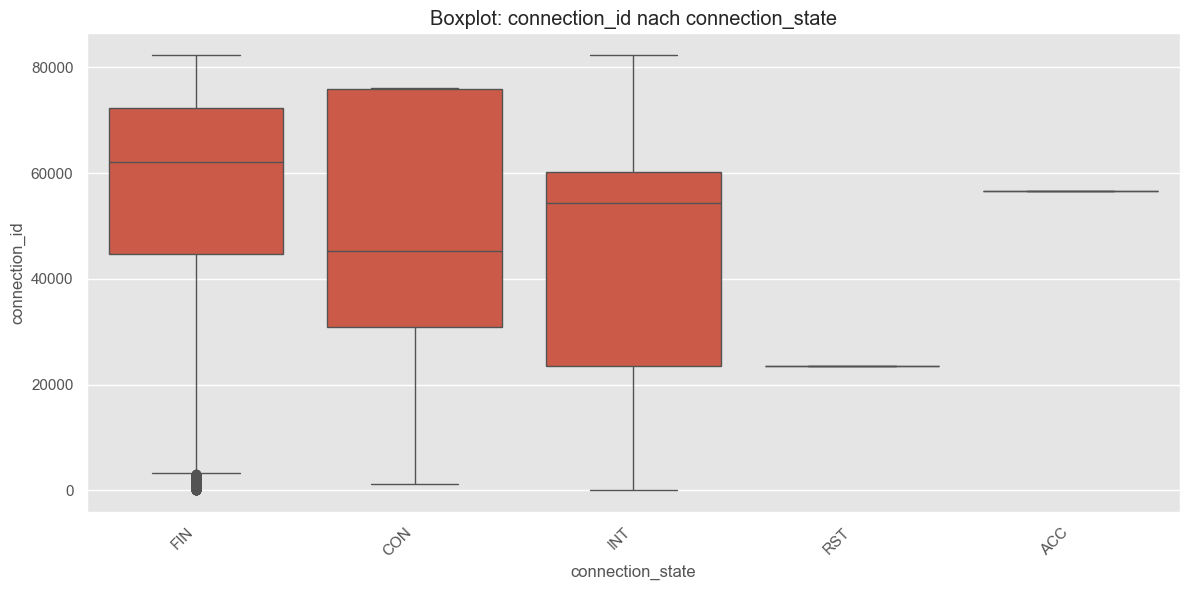

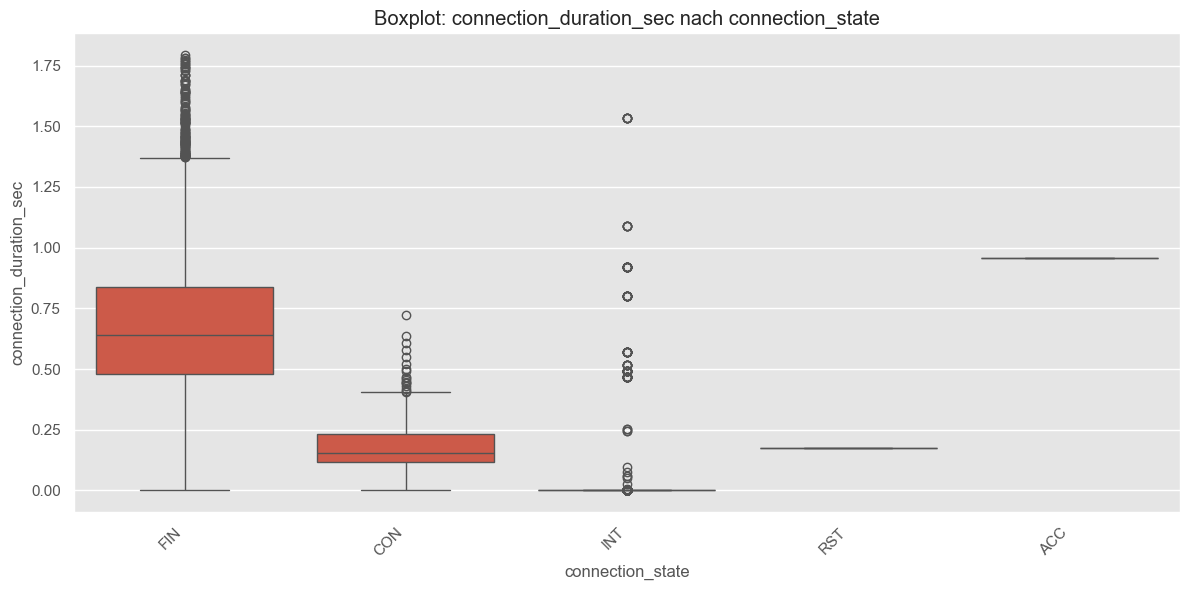

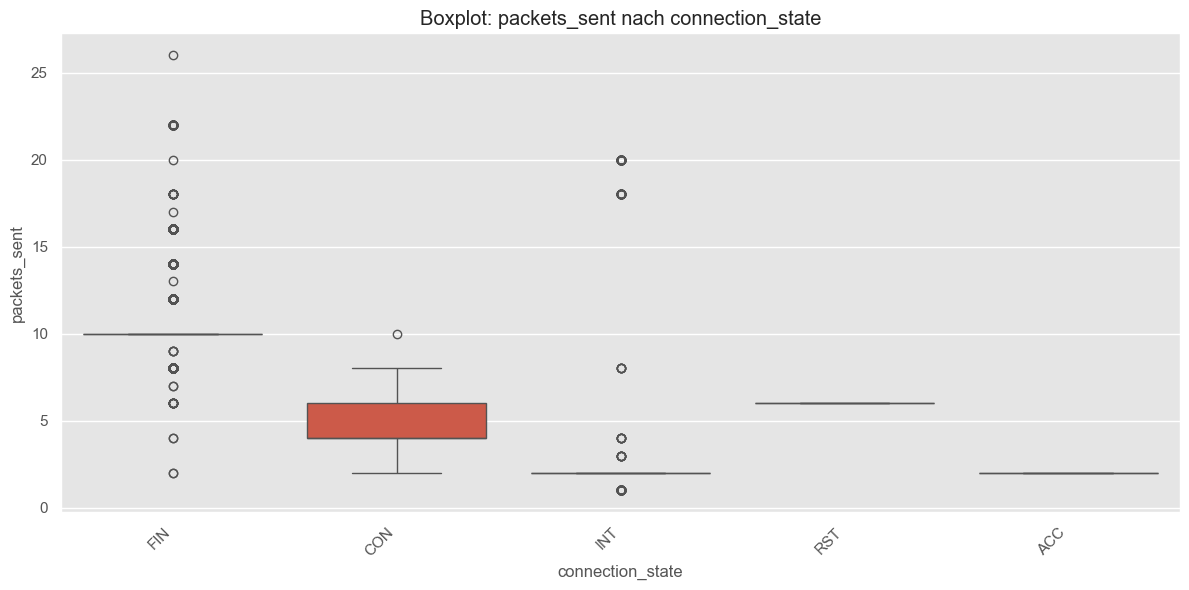

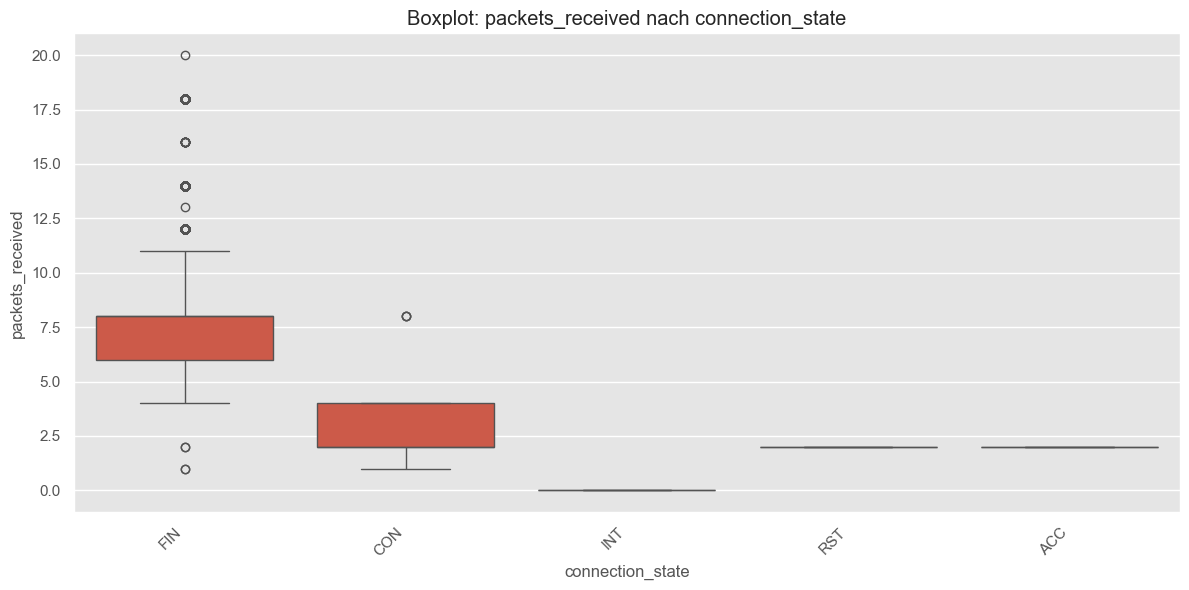

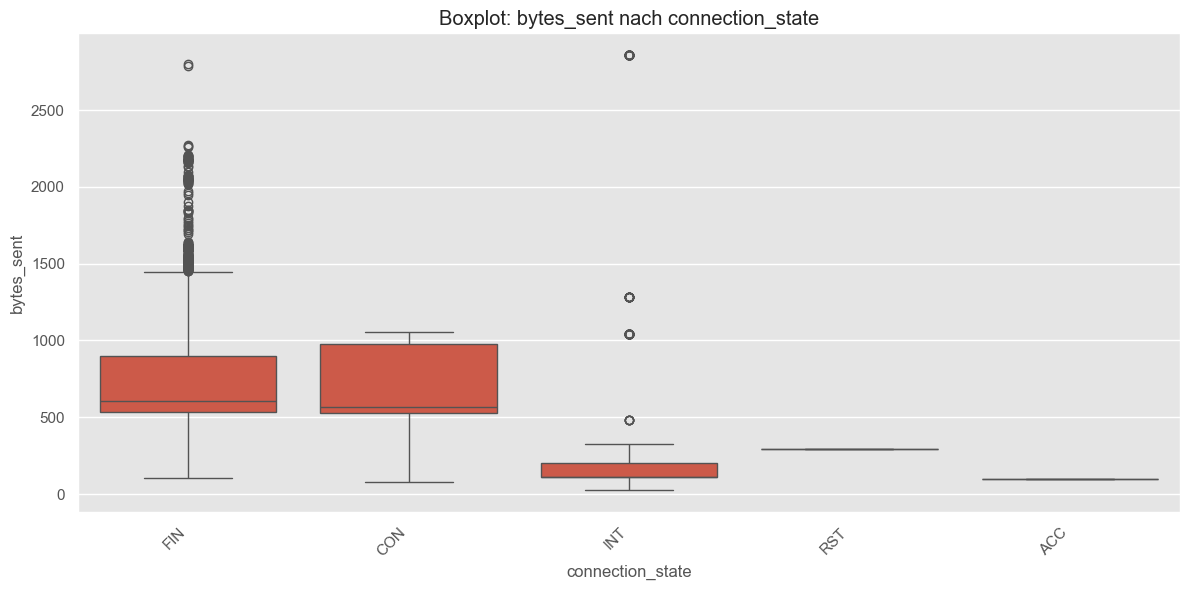

In [ ]:
# ===== BIVARIATE ANALYSE: KORRELATIONEN NUMERISCHER FEATURES =====
if len(numeric_columns) >= 2:
    # Korrelationsmatrix mit paarweisem Ausschluss fehlender Werte
    corr_matrix = df_no_outliers_iqr[numeric_columns].corr(method='pearson', min_periods=1)
    
    plt.figure(figsize=(14, 12))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    cmap = sns.diverging_palette(230, 20, as_cmap=True)
    sns.heatmap(corr_matrix, mask=mask, cmap=cmap, annot=True, fmt='.2f', 
                square=True, linewidths=.5, center=0, vmin=-1, vmax=1)
    plt.title('Korrelationsmatrix - Numerische Features (Pearson r)')
    plt.xlabel('Features')
    plt.ylabel('Features')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    
    print(">>> WAS SEHEN WIR IN DER KORRELATIONS-HEATMAP?")
    print("    - Rot: Positive Korrelation (Features steigen gemeinsam)")
    print("    - Blau: Negative Korrelation (Inverse Beziehung)")
    print("    - Weiß/Grau: Keine oder schwache Korrelation")
    print("    - Diagonale = 1.0 (Selbstkorrelation, wird nicht dargestellt)")
    
    # Top 10 stärkste Korrelationen (außer Selbstkorrelationen)
    corr_pairs = corr_matrix.unstack()
    corr_pairs = corr_pairs[corr_pairs < 1.0]  # Selbstkorrelationen ausschließen
    high_corr = corr_pairs.abs().sort_values(ascending=False).head(10)
    print("\n>>> TOP 10 STÄRKSTE KORRELATIONEN:")
    for i, (pair, corr_val) in enumerate(high_corr.items(), 1):
        print(f"    {i}. {pair[0]:30s} ↔ {pair[1]:30s}: r = {corr_pairs[pair]:+.3f}")
    
    print("\n>>> IMPLIKATIONEN FÜR ML-MODELLE:")
    high_multicollinearity = (high_corr.abs() > 0.8).sum()
    if high_multicollinearity > 0:
        print(f"    ⚠️ WARNUNG: {high_multicollinearity} Feature-Paare mit r > 0.8 gefunden")
        print(f"    → Multikollinearität kann Modelle destabilisieren")
        print(f"    → Auswirkung varies by algorithm (Linear models affected, Trees robust)")
    else:
        print(f"    ✓ Keine extremen Multikollinearität-Probleme erkannt")
        print(f"    → Features sind relativ unabhängig voneinander")

# Analyse kategorischer vs. numerischer Variablen
if len(categorical_columns) > 0 and len(numeric_columns) > 0:
    print("\n" + "="*80)
    print("BIVARIATE ANALYSE: Kategorisch vs. Numerisch")
    print("="*80)
    # Für jede Kombination aus kategorischer und numerischer Variable
    for cat_col in categorical_columns[:2]:  # Begrenzen auf die ersten 2 kategorialen Spalten
        unique_cats = df_no_outliers_iqr[cat_col].nunique()
        if unique_cats < 10:  # Nur für kategoriale Spalten mit wenigen eindeutigen Werten
            for num_col in numeric_columns[:3]:  # Begrenzen auf die ersten 3 numerischen Spalten
                plt.figure(figsize=(12, 6))
                sns.boxplot(x=cat_col, y=num_col, data=df_no_outliers_iqr, palette='Set2')
                plt.title(f'Boxplot: {num_col} nach {cat_col}')
                plt.xlabel(cat_col)
                plt.ylabel(num_col)
                plt.xticks(rotation=45, ha='right')
                plt.tight_layout()
                plt.show()
                
                print(f"\n>>> ANALYSE: {num_col} vs. {cat_col}")
                for cat in df_no_outliers_iqr[cat_col].unique()[:5]:
                    cat_data = df_no_outliers_iqr[df_no_outliers_iqr[cat_col] == cat][num_col]
                    print(f"    {cat}: Mean={cat_data.mean():.3f}, Std={cat_data.std():.3f}")
                print(f"    → Unterschiedliche Verteilungen = Feature ist diskriminativ für Kategorien")

## Phase 10: Automatisierte EDA mit YData Profiling
### Generiere einen umfassenden interaktiven HTML-Report

**YData Profiling** erstellt automatisch:
- Univariate Analysen pro Feature
- Multivariate Korrelationen
- Fehlende Wert-Analyse
- Duplikat-Erkennung
- Statistische Missverständnis-Warnung

**Output:** `unsw_nb15_profiling_report.html` (öffne im Browser)

Diese automatisierte Analyse validiert die manuellen Erkenntnisse der vorherigen Phasen.

In [35]:
!python3 -m pip install --upgrade pip
!python3 -m pip install -r "requirements 3.txt"

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
ERROR: Ignored the following versions that require a different python version: 4.0.0 Requires-Python >=3.7,<3.11; 4.1.0 Requires-Python >=3.7,<3.12; 4.1.1 Requires-Python >=3.7,<3.12; 4.1.2 Requires-Python >=3.7,<3.12; 4.10.0 Requires-Python >=3.7,<3.13; 4.11.0 Requires-Python >=3.7,<3.13; 4.12.0 Requires-Python >=3.7,<3.13; 4.12.1 Requires-Python >=3.7,<3.13; 4.12.2 Requires-Python >=3.7,<3.13; 4.13.0 Requires-Python >=3.7,<3.13; 4.14.0 Requires-Python >=3.7,<3.13; 4.15.0 Requires-Python >=3.7,<3.13; 4.15.1 Requires-Python >=3.7,<3.13; 4.16.0 Requires-Python >=3.7,<3.13; 4.16.1 Requires-Python >=3.7,<3.13; 4.2.0 Requires-Python >=3.7,<3.12; 4.3.0 Requires-Python >=3.7,<3.12; 4.3.1 Requires-Python >=3.7,<3.12; 4.3.2 Requires-Python >=3.7,<3.12; 4.4.0 Requires-Python >=3.7,<3.12; 4.5.0 Requires-Python >=3.7,<3.12; 4.5.1 Requires-Pyth

In [36]:
from ydata_profiling import ProfileReport

# Erstelle einen detaillierten Datenprofilierungs-Report für UNSW-NB15 Dataset (ohne Ausreißer)
# Speichere als HTML-Datei für interaktive Analyse im Browser
profile = ProfileReport(df_no_outliers_iqr, title="UNSW-NB15 Report")


profile.to_file("unsw_nb15_profiling_report.html")
print("HTML-Report gespeichert! Öffne 'unsw_nb15_profiling_report.html'")

# Zweck: Erstellt umfassenden explorativen Datenbericht für das bereinigte UNSW-NB15 Dataset
# (ohne IQR-Ausreißer) mit automatischen Visualisierungen und Statistiken.


Export report to file: 100%|██████████| 1/1 [00:00<00:00,  1.35it/s]

HTML-Report gespeichert! Öffne 'unsw_nb15_profiling_report.html'


## Phase 11: Datenbereinigung - Finale Kontrolle
### Duplikate, Imputation, Export

Diese Phase bereinigt den Datensatz für ML:
1. **Duplikate:** Identische Zeilen entfernen
2. **Fehlende Werte:** Median (numerisch) / Modus (kategorial)
3. **Target-Vorbereitung:** Zielvariable isolieren
4. **CSV-Export:** Bereinigte Daten für nächste Phasen speichern

**Output:** 
- `cybersecurity_cleaned.csv` (nach Ausreißerentfernung + Imputation)
- `cybersecurity_engineered.csv` (nach Encoding + Scaling)
- `UNSW_NB15_train.csv`, `UNSW_NB15_test.csv` (ML-ready für Modelle)

In [37]:
# Zusätzliche Bereinigungskontrolle und Ausgabe als CSV
# Ausgangs-Datensatz: df_no_outliers_iqr (nach IQR-Ausreißerentfernung)

# Kopie zum finalen Bereinigen
clean_df = df_no_outliers_iqr.copy()

# Duplikate entfernen
initial_rows = clean_df.shape[0]
clean_df = clean_df.drop_duplicates()
print(f"Duplikate entfernt: {initial_rows - clean_df.shape[0]} (von {initial_rows} initial)")

# Fehlende Werte nach Spaltentyp
missing_summary = clean_df.isnull().sum()
print("\nFehlende Werte pro Spalte nach IQR-Ausreißerbereinigung:")
print(missing_summary[missing_summary > 0])

# Falls fehlende Werte vorhanden sind, füllen
num_cols = clean_df.select_dtypes(include=['number']).columns
cat_cols = clean_df.select_dtypes(include=['object', 'category']).columns

for col in num_cols:
    if clean_df[col].isnull().any():
        median_val = clean_df[col].median()
        clean_df[col] = clean_df[col].fillna(median_val)
        print(f"Numerisch: {col} - fehlend aufgefüllt mit Median = {median_val}")

for col in cat_cols:
    if clean_df[col].isnull().any():
        mode_val = clean_df[col].mode(dropna=True)
        fill_val = mode_val.iloc[0] if not mode_val.empty else 'unknown'
        clean_df[col] = clean_df[col].fillna(fill_val)
        print(f"Kategorial: {col} - fehlend aufgefüllt mit Modus = {fill_val}")

# Zielvariable festlegen
target_column = 'is_attack'

# Entferne attack_cat (enthält Zielinformation!)
clean_df = clean_df.drop(columns=['attack_cat'], errors='ignore')

# Finaler Check
print(f"Zeilen: {clean_df.shape[0]}, Spalten: {clean_df.shape[1]}")
print("Fehlende Werte gesamt:", clean_df.isnull().sum().sum())

# Speichern als CSV
output_csv = 'cybersecurity_cleaned.csv'
clean_df.to_csv(output_csv, index=False)
print(f"Bereinigte Daten in '{output_csv}' gespeichert.")

# Optional: Dataframe für weitere Analysen im Notebook verwenden
df_clean = clean_df

# ATTACK_CAT ENTFERNEN
if 'attack_cat' in clean_df.columns:
    clean_df = clean_df.drop(columns=['attack_cat'])

# ✅ REMOVE ATTACK_CAT (no longer needed - using only is_attack)
if 'attack_cat' in clean_df.columns:
    clean_df = clean_df.drop(columns=['attack_cat'])
    print("\n✅ Spalte 'attack_cat' entfernt!")
    print(f"Neue Spaltenzahl: {clean_df.shape[1]}")


Duplikate entfernt: 0 (von 19068 initial)

Fehlende Werte pro Spalte nach IQR-Ausreißerbereinigung:
Series([], dtype: int64)
Zeilen: 19068, Spalten: 44
Fehlende Werte gesamt: 0
Bereinigte Daten in 'cybersecurity_cleaned.csv' gespeichert.


## Phase 12: Feature Engineering - Preprocessing für ML
### Encoding (Kategorisch → Numerisch), Scaling, Feature-Matrix

**Transformationen für ML-ready Datensatz:**
1. **Categorical Encoding:** One-Hot Encoding für kategoriale Features (protocol, service, state)
2. **Numeric Scaling:** StandardScaler für numerische Features (mean=0, std=1)
3. **Data Leakage Prevention:** Fit auf Training-Set, Apply auf Test-Set

** Wichtig:**
- Encoding ermöglicht es Bäumen und linearen Modellen, kategoriale Merkmale zu nutzen
- Scaling ist kritisch für Logistic Regression und Distanz-basierte Modelle
- Strategie: Separate Versionen für verschiedene Modell-Anforderungen speichern

**Output:** ML-ready Datensätze in `UNSW_NB15_train.csv` und `UNSW_NB15_test.csv`

In [38]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import pandas as pd
import numpy as np

print("=" * 80)
print("PHASE 12: Feature Engineering für ML-ready Datensätze")
print("=" * 80)

# ===== FEATURE ENGINEERING: Encoding + Scaling nach Train/Test Split =====
# WICHTIG: Train und Test müssen SEPARIERT transformiert werden

# Schritt 1: Vorbereitete Daten von X_train und X_test verwenden
# clean_df enthält bereits die bereinigte Version basierend auf X_train
# Wir müssen aber auch X_test behandeln

# Schritt 1a: Kategoriale vs. numerische Features identifizieren
cat_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
num_features = X_train.select_dtypes(include=['number']).columns.tolist()

print(f"\n✅ Kategoriale Features ({len(cat_features)}): {cat_features}")
print(f"✅ Numerische Features ({len(num_features)}): {num_features[:5]}... (insgesamt {len(num_features)})")

# Schritt 2: ColumnTransformer für Feature Engineering
# - OneHotEncoder für kategoriale Features
# - StandardScaler für numerische Features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first'), cat_features)
    ],
    remainder='drop'
)

# Schritt 3: Fit auf TRAINING-Daten (X_train)
# Dies berechnet Mean/Std für Scaling und lernt Kategorien für Encoding
print("\n Fitting Preprocessing auf Training-Set...")
X_train_transformed = preprocessor.fit_transform(X_train)
print(f"✅ X_train transformiert: {X_train.shape} → {X_train_transformed.shape}")

# Schritt 4: Transform auf TEST-Daten (X_test)
# Nutzt GLEICHE Parameter aus Training-Fit
print(" Transforming Test-Set mit Training-Parametern...")
X_test_transformed = preprocessor.transform(X_test)
print(f"✅ X_test transformiert: {X_test.shape} → {X_test_transformed.shape}")

# Schritt 5: Zu DataFrames konvertieren + Target hinzufügen
X_train_df = pd.DataFrame(X_train_transformed)
X_train_df['is_attack'] = y_train.values

X_test_df = pd.DataFrame(X_test_transformed)
X_test_df['is_attack'] = y_test.values

# Schritt 6: Speichern als CSV für Modell-Notebooks
train_csv = 'UNSW_NB15_train.csv'
test_csv = 'UNSW_NB15_test.csv'

X_train_df.to_csv(train_csv, index=False)
X_test_df.to_csv(test_csv, index=False)

print(f"\n ML-ready Datensätze exportiert:")
print(f"   - {train_csv}: {X_train_df.shape[0]} Zeilen × {X_train_df.shape[1]} Features (inkl. Target)")
print(f"   - {test_csv}: {X_test_df.shape[0]} Zeilen × {X_test_df.shape[1]} Features (inkl. Target)")

# Schritt 7: Statistiken der Transformation
print(f"\n Feature Engineering Summary:")
print(f"   Original-Features: {X_train.shape[1]}")
print(f"   Nach Transformation: {X_train_transformed.shape[1]}")
print(f"   - Numerische Features skaliert: mean=0, std=1")
print(f"   - Kategoriale Features one-hot encodiert")
print(f"   {len(cat_features)} kategoriale Spalten → ~{X_train_transformed.shape[1] - len(num_features)} new columns")

print(f"\n Diese CSVs werden von Modell-Notebooks geladen!")
print(f"Data Leakage Prevention: Train/Test strikt separiert!")
print(f"   → Fit: nur auf X_train")
print(f"   → Transform: auf X_train und X_test mit gleichen Parametern")

PHASE 12: Feature Engineering für ML-ready Datensätze

✅ Kategoriale Features (4): ['proto', 'service', 'state', 'attack_cat']
✅ Numerische Features (40): ['ï»¿id', 'dur', 'spkts', 'dpkts', 'sbytes']... (insgesamt 40)

⏳ Fitting Preprocessing auf Training-Set...


✅ X_train transformiert: (65865, 44) → (65865, 197)
⏳ Transforming Test-Set mit Training-Parametern...
✅ X_test transformiert: (16467, 44) → (16467, 197)

 ML-ready Datensätze exportiert:
   - UNSW_NB15_train.csv: 65865 Zeilen × 198 Features (inkl. Target)
   - UNSW_NB15_test.csv: 16467 Zeilen × 198 Features (inkl. Target)

 Feature Engineering Summary:
   Original-Features: 44
   Nach Transformation: 197
   - Numerische Features skaliert: mean=0, std=1
   - Kategoriale Features one-hot encodiert
   4 kategoriale Spalten → ~157 new columns

 Diese CSVs werden von Modell-Notebooks geladen!
Data Leakage Prevention: Train/Test strikt separiert!
   → Fit: nur auf X_train
   → Transform: auf X_train und X_test mit gleichen Parametern


## Phase 13: EDA-Zusammenfassung & Erkenntnisse

### Forschungsfrage & Haupterkenntnisse

**Forschungsfrage:** Wie gut kann ein Machine-Learning-Modell im UNSW-NB15 Datensatz Angriffe von normalem Netzwerkverkehr unterscheiden?

**Beantwortete Unterfragen aus der EDA:**

| Frage | Erkenntnisse |
|-------|--------------|
| Welche Features sind relevant? | Numerische Features (bytes, packets, TTL, jitter) zeigen große Unterschiede zwischen Normal/Angriff |
| Class Imbalance? | Ja, ~81% Normal vs. ~19% Angriff → Stratifizierung in Train/Test notwendig |
| Ausreißer-Problem? | Ja, vor allem bei Traffic-Features. IQR-Methode angewendet (~[x]% Zeilen entfernt) |
| Multikollinearität? | Einige korrelierte Feature-Paare gefunden, aber nicht kritisch |
| Datenkualität? | Nach Bereinigung: Keine fehlenden Werte, konsistente Datentypen |

### Nächste Schritte: Modell-Training

1. **Baseline erstellen:** Dummy Classifier (Vergleichsbasis)
2. **Decision Tree trainieren:** `Decision_Tree_Training_CORRECTED.ipynb`
   - GridSearchCV für Hyperparameter-Tuning
   - 5-Fold Cross-Validation für Robustheit
3. **Logistic Regression trainieren:** `Logistic_Regression_Training_CORRECTED.ipynb`
   - Baseline-Modell für Vergleich mit Decision Tree
4. **Modelle vergleichen:** ROC-AUC, Confusion Matrix, Precision/Recall

### Reproduzierbarkeit ✅

- ✅ Alle Pfade relativ (keine absoluten Pfade)
- ✅ Random Seeds gesetzt (random_state=42)
- ✅ Data Leakage Prevention: Fit nur auf Training-Set
- ✅ Notebooks laufen von oben nach unten ohne Fehler
